# 导入

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr 
 
import matplotlib.colors as colors 
from matplotlib.colors import TwoSlopeNorm
from matplotlib import colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from mpl_toolkits.axisartist.parasite_axes import HostAxes, ParasiteAxes
import cartopy.io.shapereader as sr
import cartopy.feature as cfeature
from cartopy.mpl import geoaxes
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker

from scipy.stats import pearsonr
from scipy.stats import linregress

from matplotlib import font_manager
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import cmaps
import seaborn  as sns

Text(1995, 0.248, 'y=0.0003x-0.387  p<0.05')

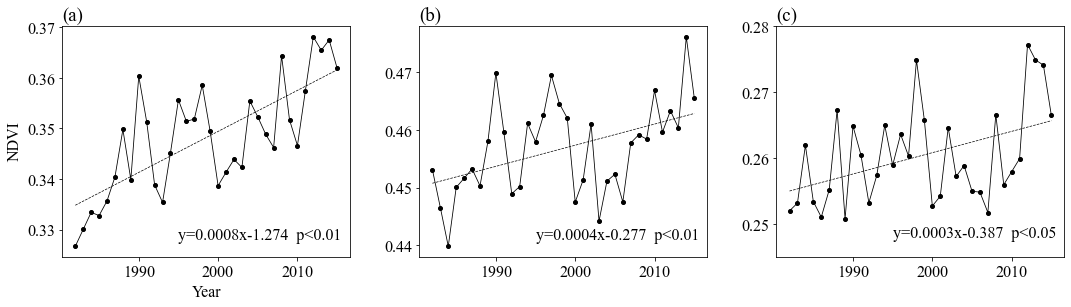

In [2]:
#读取文件
indices_mean =  pd.read_csv('G:/cn05/cn05_huabei/output/indices_mean.csv')
indices_mean = indices_mean[['TXX', 'TXN', 'TNN', 'TNX', 'TX90', 'TX10', 'TN90', 'TN10', 'DTR', 'R1xday', 'R1mm', 'R10mm', 'R20mm']]
indices_mean = np.array(indices_mean)

ndvi_mean = pd.read_csv('G:/cn05/cn05_huabei/output/ndvi_mean.csv')
ndvi_mean = ndvi_mean['NDVI']
ndvi_mean = np.array(ndvi_mean)

ndvi_mean_1112 = pd.read_csv('G:/tudi_ndvi/output/1112_ndvi_mean.csv')
ndvi_mean_2124 = pd.read_csv('G:/tudi_ndvi/output/2124_ndvi_mean.csv')
ndvi_mean_3133 = pd.read_csv('G:/tudi_ndvi/output/3133_ndvi_mean.csv')

ndvi_mean_1112 = ndvi_mean_1112['NDVI']
ndvi_mean_2124 = ndvi_mean_2124['NDVI']
ndvi_mean_3133 = ndvi_mean_3133['NDVI']

ndvi_year = np.load('G:/cn05/cn05_huabei/output/ndvi_year.npz')
ndvi_area_mean = ndvi_year['NDVI_mean']
ndvi_year_mean = ndvi_year['NDVI_year_mean']

ndvi_month = np.load('G:/cn05/cn05_huabei/output/month_correlation.npz')
ndvi_month_r = ndvi_month['ndvi_month_r']

indices = np.array(['Tm','TXX', 'TXN', 'TNN', 'TNX', 'TX90', 'TX10', 'TN90', 'TN10', 'DTR', 'pre','R1xday', 'R1mm', 'R10mm', 'R20mm'])
month = np.arange(1,13,1)
#x轴年份
year = np.arange(1982,2016,1)

#求线性趋势
s1,d1,r1,p1,_ = linregress(year,ndvi_mean)
s2,d2,r2,p2,_ = linregress(year,ndvi_mean_1112)
s3,d3,r3,p3,_ = linregress(year,ndvi_mean_2124)
s4,d4,r4,p4,_ = linregress(year,ndvi_mean_3133)

#设置图纸大小
fig=plt.figure(figsize=(8,8))

#设置字体和字号
plt.rcParams['font.sans-serif'] = 'Times New Roman'
plt.rcParams['font.size'] = '16'


#第一个图的位置
ax1 = fig.add_axes([0.0,0.0,0.5,0.4])
#折线图
ax1.plot(year,ndvi_mean_1112,lw=0.8,marker='o',color='k',ms='4')
#设置标题
ax1.set_title('(a)',loc='left')
#加入线性趋势
ax1.plot(year,s2*year+d2,'k--',lw=0.7)
#加入xy轴标签
ax1.set_xlabel('Year')
ax1.set_ylabel('NDVI')
#加入标注
ax1.text(1995,0.328,'y=0.0008x-1.274  p<0.01')


ax1 = fig.add_axes([0.62,0.0,0.5,0.4])
#折线图
ax1.plot(year,ndvi_mean_2124,lw=0.8,marker='o',color='k',ms='4')
#设置标题
ax1.set_title('(b)',loc='left')
#加入线性趋势
ax1.plot(year,s3*year+d3,'k--',lw=0.7)
#加入xy轴标签
#加入标注
ax1.text(1995,0.441,'y=0.0004x-0.277  p<0.01')

ax1 = fig.add_axes([1.24,0.0,0.5,0.4])
#折线图
ax1.plot(year,ndvi_mean_3133,lw=0.8,marker='o',color='k',ms='4')
#设置标题
ax1.set_title('(c)',loc='left')
#加入线性趋势
ax1.plot(year,s4*year+d4,'k--',lw=0.7)
ax1.set_ylim(0.245,0.28)
#加入xy轴标签
#加入标注
ax1.text(1995,0.248,'y=0.0003x-0.387  p<0.05')

#fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\veg_Temporal.pdf',format='pdf',dpi=600,bbox_inches = 'tight')


Text(1990, 48, 'y = −0.2458x + 527.8')

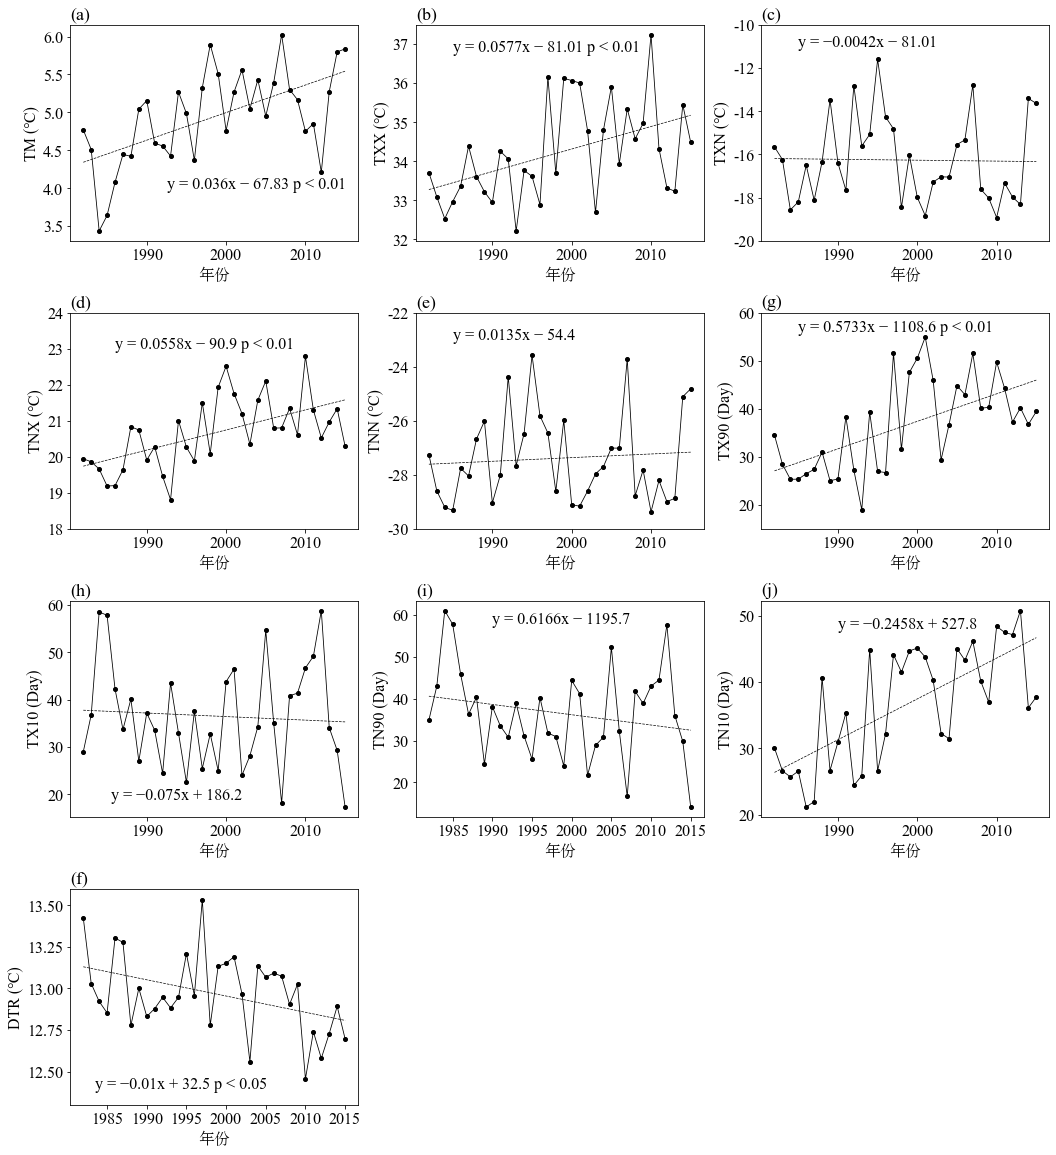

In [3]:
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
#print(prop.get_name())  # 显示当前使用字体的名称

plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

mean_mean = pd.read_csv('G:/cn05/cn05_huabei/output/mean_mean.csv')
tm_mean = np.array(mean_mean['tm'])
pre_mean = np.array(mean_mean['pre'])

indices_mean = pd.read_csv('G:/cn05/cn05_huabei/output/indices_mean.csv')
txx_mean = np.array(indices_mean['TXX'])
tnx_mean = np.array(indices_mean['TNX'])
txn_mean = np.array(indices_mean['TXN'])
tnn_mean = np.array(indices_mean['TNN'])
tx90_mean = np.array(indices_mean['TX90'])
tn90_mean = np.array(indices_mean['TN90'])
tx10_mean = np.array(indices_mean['TX10'])
tn10_mean = np.array(indices_mean['TN10'])
dtr_mean = np.array(indices_mean['DTR'])
r1xday_mean = np.array(indices_mean['R1xday'])
r1mm_mean = np.array(indices_mean['R1mm'])
r10mm_mean = np.array(indices_mean['R10mm'])
r20mm_mean = np.array(indices_mean['R20mm'])


slope_mean = np.array([tm_mean,txx_mean,tnx_mean,txn_mean,tnn_mean,tx90_mean,tn90_mean,tx10_mean,tn10_mean,dtr_mean,pre_mean,r1xday_mean,r1mm_mean,r10mm_mean,r20mm_mean])

s = np.full((15),fill_value=np.nan)
d = np.full((15),fill_value=np.nan)
p = np.full((15),fill_value=np.nan)
r = np.full((15),fill_value=np.nan)

for i in range(15):
    s[i],d[i],r[i],p[i],_ = linregress(year,slope_mean[i])

fig=plt.figure(figsize=(10,10))

font = {'weight': 'bold','size': 18}

ax1 = fig.add_axes([0, 0, 0.4, 0.3])
ax1.set_xlabel('年份')
ax1.set_ylabel('TM (℃)')
ax1.set_title('(a)',font,loc='left')
ax1.plot(year,tm_mean,lw=0.8,marker='o',color='k',ms='4')
ax1.plot(year,s[0]*year+d[0],'k--',lw=0.7)
ax1.text(1992,4.0,' y = 0.036x − 67.83 p < 0.01')

ax2 = fig.add_axes([0.48, 0, 0.4, 0.3])
ax2.set_xlabel('年份')
ax2.set_ylabel('TXX (℃)')
ax2.set_title('(b)',font,loc='left')
ax2.plot(year,txx_mean,lw=0.8,marker='o',color='k',ms='4')
ax2.plot(year,s[1]*year+d[1],'k--',lw=0.7)
ax2.text(1985,36.8,'y = 0.0577x − 81.01 p < 0.01')


ax3 = fig.add_axes([0.96, 0, 0.4, 0.3])
ax3.set_xlabel('年份')
ax3.set_ylabel('TXN (℃)')
ax3.set_title('(c)',font,loc='left')
ax3.plot(year,txn_mean,lw=0.8,marker='o',color='k',ms='4')
ax3.plot(year,s[3]*year+d[3],'k--',lw=0.7)
ax3.text(1985,-11,'y = −0.0042x − 81.01')
ax3.set_ylim(-20,-10)


ax4 = fig.add_axes([0.0, -0.4, 0.4, 0.3])
ax4.set_xlabel('年份')
ax4.set_ylabel('TNX (℃)')
ax4.set_title('(d)',font,loc='left')
ax4.plot(year,tnx_mean,lw=0.8,marker='o',color='k',ms='4')
ax4.plot(year,s[2]*year+d[2],'k--',lw=0.7)
ax4.text(1986,23,'y = 0.0558x − 90.9 p < 0.01')
ax4.set_ylim(18,24)

ax5 = fig.add_axes([0.48, -0.4, 0.4, 0.3])
ax5.set_xlabel('年份')
ax5.set_ylabel('TNN (℃)')
ax5.set_title('(e)',font,loc='left')
ax5.plot(year,tnn_mean,lw=0.8,marker='o',color='k',ms='4')
ax5.plot(year,s[4]*year+d[4],'k--',lw=0.7)
ax5.text(1985,-23,'y = 0.0135x − 54.4')
ax5.set_ylim(-30,-22)

ax6 = fig.add_axes([0.0, -1.2, 0.4, 0.3])
ax6.set_xlabel('年份')
ax6.set_ylabel('DTR (℃)')
ax6.set_title('(f)',font,loc='left')
ax6.plot(year,dtr_mean,lw=0.8,marker='o',color='k',ms='4')
ax6.plot(year,s[9]*year+d[9],'k--',lw=0.7)
ax6.text(1983,12.4,' y = −0.01x + 32.5 p < 0.05')
ax6.set_ylim(12.3,13.6)
ax6.set_xticks([1985,1990,1995,2000,2005,2010,2015])


ax7 = fig.add_axes([0.96, -0.4, 0.4, 0.3])
ax7.set_xlabel('年份')
ax7.set_ylabel('TX90 (Day)')
ax7.set_title('(g)',font,loc='left')
ax7.plot(year,tx90_mean,lw=0.8,marker='o',color='k',ms='4')
ax7.plot(year,s[5]*year+d[5],'k--',lw=0.7)
ax7.text(1985,56,'y = 0.5733x − 1108.6 p < 0.01 ',c='k')
ax7.set_ylim(15,60)

ax8 = fig.add_axes([0.0, -0.8, 0.4, 0.3])
ax8.set_xlabel('年份')
ax8.set_ylabel('TX10 (Day)')
ax8.set_title('(h)',font,loc='left')
ax8.plot(year,tx10_mean,lw=0.8,marker='o',color='k',ms='4')
ax8.plot(year,s[7]*year+d[7],'k--',lw=0.7)
ax8.text(1985,19,' y = −0.075x + 186.2',c='k')

ax9 = fig.add_axes([0.48, -0.8, 0.4, 0.3])
ax9.set_xlabel('年份')
ax9.set_ylabel('TN90 (Day)')
ax9.set_title('(i)',font,loc='left')
ax9.plot(year,tn10_mean,lw=0.8,marker='o',color='k',ms='4')
ax9.plot(year,s[8]*year+d[8],'k--',lw=0.7)
ax9.text(1990,58,'y = 0.6166x − 1195.7',c='k')
ax9.set_xticks([1985,1990,1995,2000,2005,2010,2015])

ax10 = fig.add_axes([0.96, -0.8, 0.4, 0.3])
ax10.set_xlabel('年份')
ax10.set_ylabel('TN10 (Day)')
ax10.set_title('(j)',font,loc='left')
ax10.plot(year,tn90_mean,lw=0.8,marker='o',color='k',ms='4')
ax10.plot(year,s[6]*year+d[6],'k--',lw=0.7)
ax10.text(1990,48,'y = −0.2458x + 527.8',c='k')

#fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\tem_Temporal.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

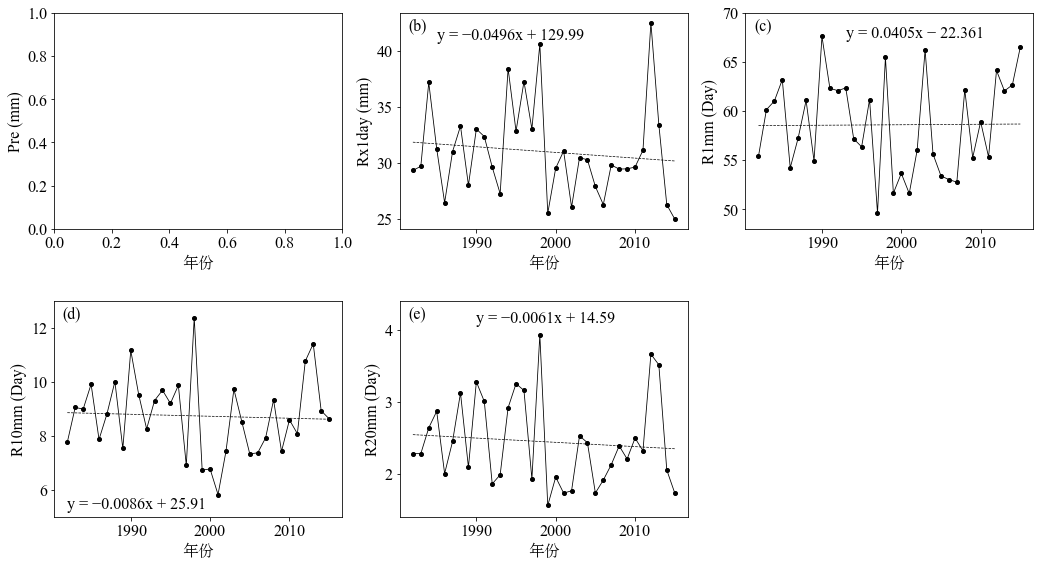

In [44]:
fig=plt.figure(figsize=(10,10))

ax11 = fig.add_axes([0, 0, 0.4, 0.3])
ax12 = fig.add_axes([0.48, 0, 0.4, 0.3])
ax13 = fig.add_axes([0.96, 0, 0.4, 0.3])
ax14 = fig.add_axes([0.0, -0.4, 0.4, 0.3])
ax15 = fig.add_axes([0.48, -0.4, 0.4, 0.3])

ax11.set_xlabel('年份')
ax11.set_ylabel('Pre (mm)')

'''
#设置y轴为科学计数法显示
# 定义样式函数
def formatnum(x, pos):
    return '%.2f×10$^{6}$' % (x/1e6)
formatter = FuncFormatter(formatnum)
plt.gca().yaxis.set_major_formatter(formatter)
ax11.set_yticks(np.linspace(0,1.2e6,16),fontsize=1)
ax11.plot(year,pre_mean,lw=0.8,marker='o',color='k',ms='4')
ax11.plot(year,s[10]*year+d[10],'k--',lw=0.7)
ax11.text(1992,740000,' y = −720.07x + 2411382.77')
ax11.text(0.03, 0.92, '(a)',transform=ax11.transAxes)
ax11.set_ylim(700000,1280000)
'''

ax12.set_xlabel('年份')
ax12.set_ylabel('Rx1day (mm)')
ax12.plot(year,r1xday_mean,lw=0.8,marker='o',color='k',ms='4')
ax12.plot(year,s[11]*year+d[11],'k--',lw=0.7)
ax12.text(1985,41,'y = −0.0496x + 129.99')
ax12.text(0.03, 0.92, '(b)',transform=ax12.transAxes)

ax13.set_xlabel('年份')
ax13.set_ylabel('R1mm (Day)')
ax13.plot(year,r1mm_mean,lw=0.8,marker='o',color='k',ms='4')
ax13.plot(year,s[12]*year+d[12],'k--',lw=0.7)
ax13.text(1993,67.5,'y = 0.0405x − 22.361')
ax13.set_ylim(48,70)
ax13.text(0.03, 0.92, '(c)',transform=ax13.transAxes)


ax14.set_xlabel('年份')
ax14.set_ylabel('R10mm (Day)')
ax14.plot(year,r10mm_mean,lw=0.8,marker='o',color='k',ms='4')
ax14.plot(year,s[13]*year+d[13],'k--',lw=0.7)
ax14.text(1982,5.3,'y = −0.0086x + 25.91')
ax14.set_ylim(5,13)
ax14.text(0.03, 0.92, '(d)',transform=ax14.transAxes)


ax15.set_xlabel('年份')
ax15.set_ylabel('R20mm (Day)')
ax15.plot(year,r20mm_mean,lw=0.8,marker='o',color='k',ms='4')
ax15.plot(year,s[14]*year+d[14],'k--',lw=0.7)
ax15.text(1990,4.1,'y = −0.0061x + 14.59')
ax15.set_ylim(1.4,4.4)
ax15.text(0.03, 0.92, '(e)',transform=ax15.transAxes)

fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\pre_Temporal2.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

c:\Users\86186\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1714: UserWarning: The following kwargs were not used by contour: 'projection'
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)


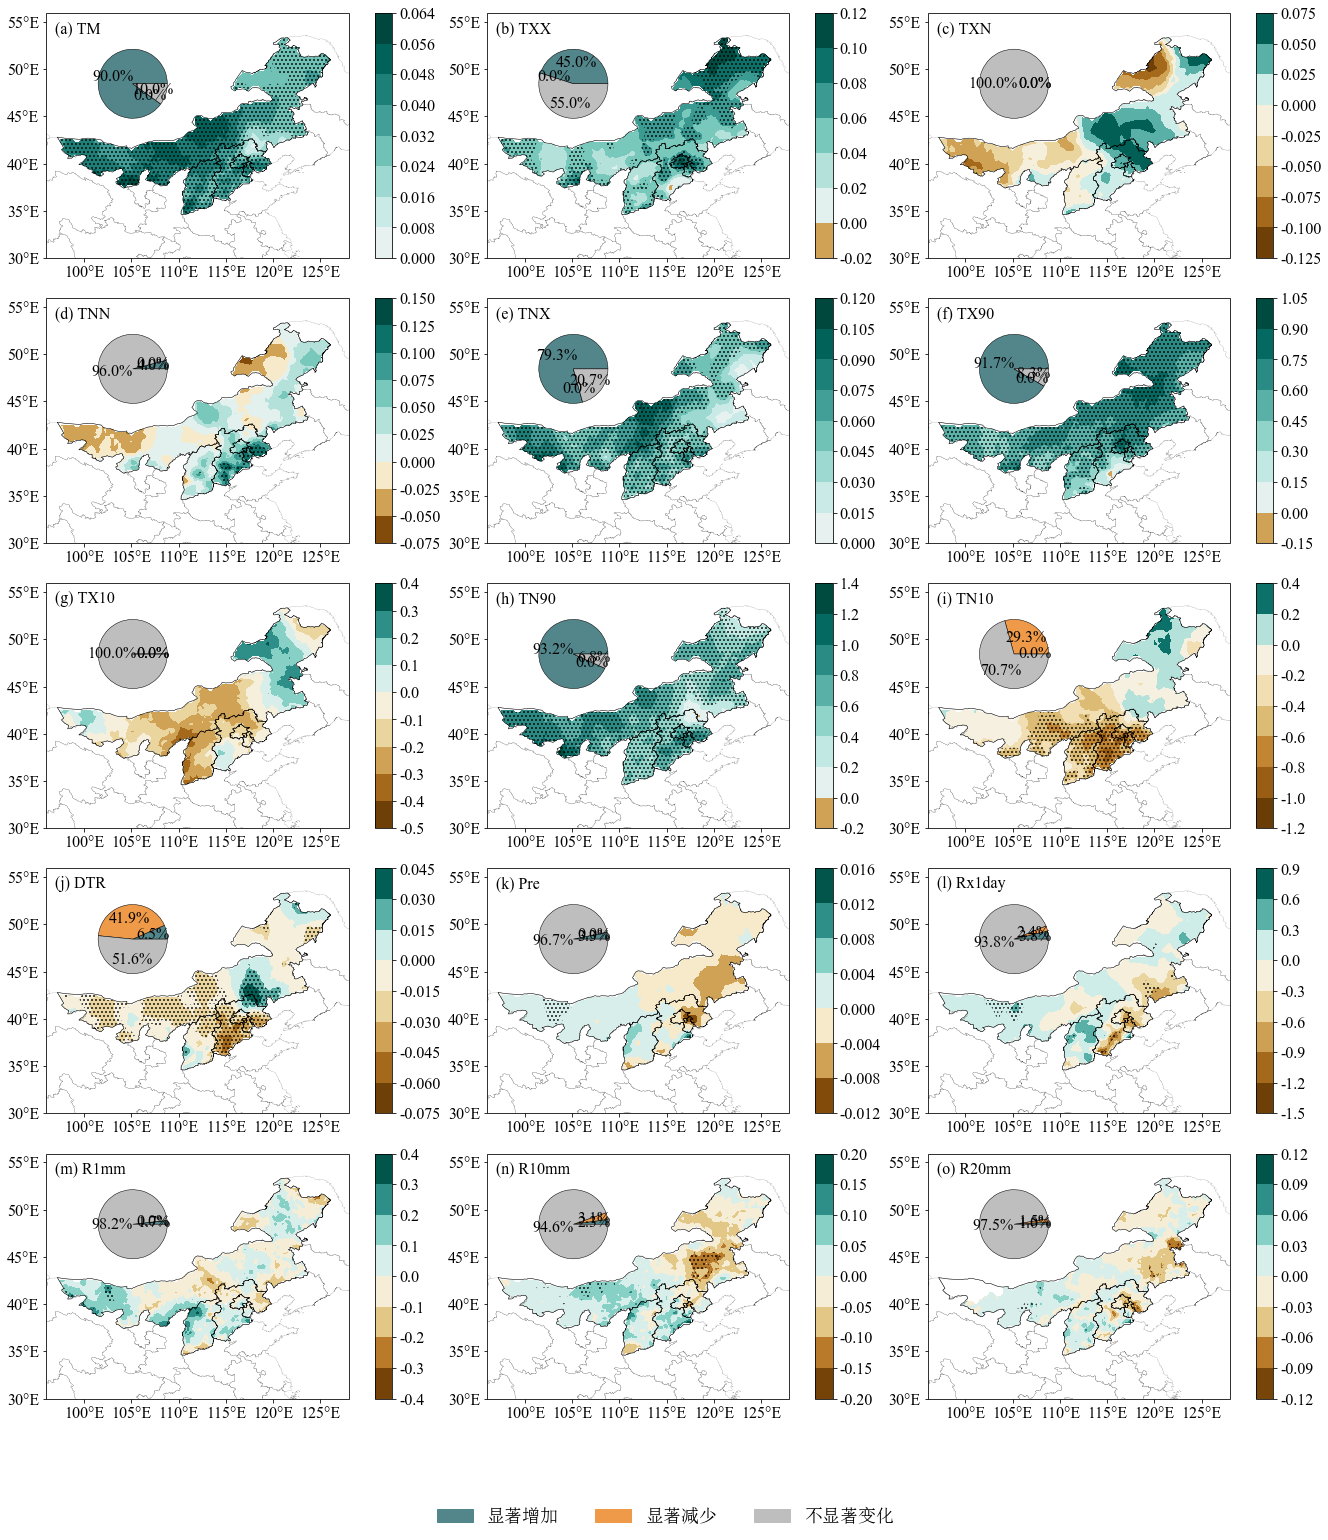

In [78]:
title = np.array(['(a) TM','(b) TXX','(c) TXN','(d) TNN','(e) TNX','(f) TX90','(g) TX10','(h) TN90','(i) TN10','(j) DTR','(k) Pre','(l) Rx1day','(m) R1mm','(n) R10mm','(o) R20mm'])
title = title.reshape((5,3))
font = {'weight': 'bold','size': 16}
#读取文件
slope =  np.load('G:/cn05/cn05_huabei/output/indices_slope.npz')
indices_slope = np.array(slope['indices_slope'])
indices_slope_p = np.array(slope['indices_slope_p'])
huabei = sr.Reader('G:/cn05/huabeishp/output/huabei_area.shp')
china = sr.Reader('G:\cn05\全国图_实习用\区划\省.shp')
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
#print(prop.get_name())  # 显示当前使用字体的名称

plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号
#显著增加，不显著增加，显著减少，不显著减少
#进行循环，分为四种情况，画饼图
lon = np.arange(95,130.25,0.25)
lat = np.arange(30,55.25,0.25)
proportion = np.full((15,3),fill_value=0)

for k in range(15):
    for i in range(101):
        for j in range(141):
            if indices_slope[k,i,j] > 0 and indices_slope_p[k,i,j] < 0.05:
                proportion[k,0] = proportion[k,0] + 1
            elif indices_slope[k,i,j] < 0 and indices_slope_p[k,i,j] < 0.05:
                proportion[k,1] = proportion[k,1] + 1
            elif indices_slope_p[k,i,j] > 0.05:
                proportion[k,2] = proportion[k,2] + 1

indices_slope = indices_slope.reshape(5,3,101,141)
indices_slope_p = indices_slope_p.reshape(5,3,101,141)
proportion = proportion.reshape(5,3,3)


fig=plt.figure(figsize=(12,12))

for i in range(5):
    for j in range(3):
        ax = fig.add_axes([0.1+j*0.51, 1.5-i*0.33, 0.35, 0.3],projection = ccrs.PlateCarree())
        norm = TwoSlopeNorm(vcenter=0)
        slope = indices_slope[i,j,:]
        slope[slope==0]=np.nan
        s = ax.contourf(lon,lat,indices_slope[i,j,:],norm = norm,cmap = 'BrBG',projection =ccrs.PlateCarree(central_longitude=112.5))
        slope_p = ax.contourf(lon,lat,indices_slope_p[i,j,:],levels=[0,0.05,1], zorder=1,hatches=['...', None],colors="none", projection =ccrs.PlateCarree(central_longitude=112.5))
        ax.add_geometries(huabei.geometries(),ccrs.PlateCarree(),facecolor='none', edgecolor='black',linewidth=0.5)
        ax.add_geometries(china.geometries(),ccrs.PlateCarree(),facecolor='none', edgecolor='black',linewidth=0.1)
        ax.set_extent([96, 128, 30, 55])
        ax.set_xticks([100, 105, 110, 115, 120, 125],crs=ccrs.PlateCarree())
        ax.set_yticks([30, 35, 40, 45, 50, 55],crs=ccrs.PlateCarree())
        #出现经纬度标签
        ax.text(0.03, 0.92, '{}'.format(title[i,j]), transform=ax.transAxes)
        ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
        ax.yaxis.set_major_formatter(cticker.LongitudeFormatter())
        cax = fig.add_axes([ax.get_position().x1+0.03,ax.get_position().y0,0.02,ax.get_position().height])
        fig.colorbar(s,cax = cax)
        ax2 = fig.add_axes([0.15+j*0.51, 1.66-i*0.33, 0.1, 0.1])
        ax2.axis('off')
        colors = ['#53868B','#EE9A49','#BEBEBE']
        ax2.pie(proportion[i,j,:],autopct='%1.1f%%',colors = colors,wedgeprops={'linewidth':0.5, 'edgecolor':'black'})


         
#设置图例分别对应三个颜色
patchs = [mpatches.Patch(color='#53868B', label='显著增加'),mpatches.Patch(color='#EE9A49', label='显著减少'),mpatches.Patch(color='#BEBEBE', label='不显著变化')]
#添加图例
fig.legend(handles=patchs,frameon=False,prop = {'size':18},bbox_to_anchor=(1.1,0.08),ncol = 3)
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\tem_Spatial.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

c:\Users\86186\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1714: UserWarning: The following kwargs were not used by contour: 'projection'
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)


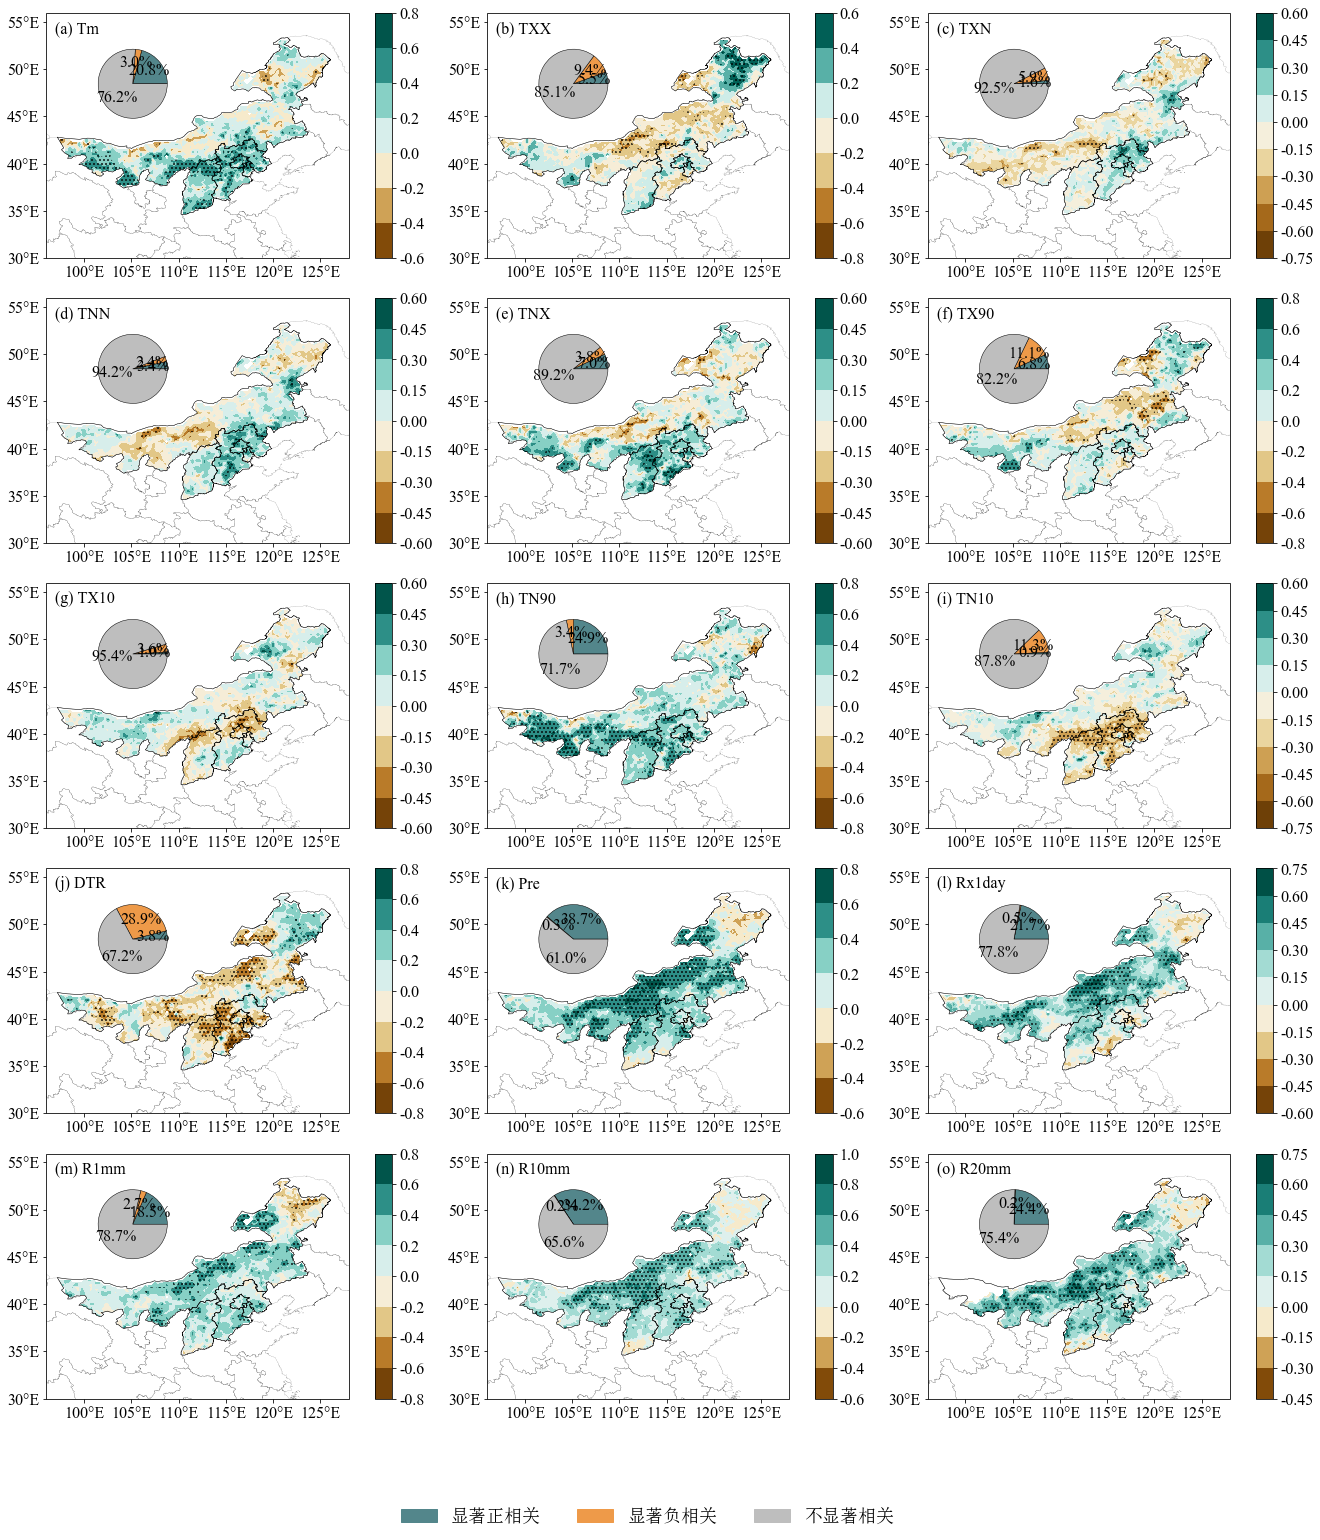

In [96]:
title = np.array(['(a) Tm','(b) TXX','(c) TXN','(d) TNN','(e) TNX','(f) TX90','(g) TX10','(h) TN90','(i) TN10','(j) DTR','(k) Pre','(l) Rx1day','(m) R1mm','(n) R10mm','(o) R20mm'])
title = title.reshape((5,3))
#读取文件
correlation =  np.load('G:/cn05/cn05_huabei/output/correlation.npz')
indices_r = np.array(correlation['inidices_year_r'])
indices_p = np.array(correlation['indices_year_p'])
huabei = sr.Reader('G:/cn05/huabeishp/output/huabei_area.shp')
china = sr.Reader('G:\cn05\全国图_实习用\区划\省.shp')

#显著正相关，不显著正相关，显著负相关，不显著负相关
#进行循环，分为四种情况，画饼图
proportion = np.full((15,3),fill_value=0)
for k in range(15):
    for i in range(101):
        for j in range(141):
            if indices_r[k,i,j] > 0 and indices_p[k,i,j] < 0.05:
                proportion[k,0] = proportion[k,0] + 1
            elif indices_r[k,i,j] < 0 and indices_p[k,i,j] < 0.05:
                proportion[k,1] = proportion[k,1] + 1
            elif indices_p[k,i,j] > 0.05:
                proportion[k,2] = proportion[k,2] + 1


plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

#把所有准备画图的数据进行变形，对应5行3列
indices_r = indices_r.reshape(5,3,101,141)
indices_p = indices_p.reshape(5,3,101,141)
proportion = proportion.reshape(5,3,3)

lon = np.arange(95,130.25,0.25)
lat = np.arange(30,55.25,0.25)

fig=plt.figure(figsize=(12,12))
for i in range(5):
    for j in range(3):
        ax = fig.add_axes([0.1+j*0.51, 1.5-i*0.33, 0.35, 0.3],projection = ccrs.PlateCarree())
        ax.text(0.03, 0.92, '{}'.format(title[i,j]), transform=ax.transAxes)
        norm = TwoSlopeNorm(vcenter=0)
        r = ax.contourf(lon,lat,indices_r[i,j,:],norm = norm,cmap = 'BrBG',projection =ccrs.PlateCarree(central_longitude=112.5))
        slope_p = ax.contourf(lon,lat,indices_p[i,j,:],levels=[0,0.05,1], zorder=1,hatches=['...', None],colors="none", projection =ccrs.PlateCarree(central_longitude=112.5))
        ax.add_geometries(huabei.geometries(),ccrs.PlateCarree(),facecolor='none', edgecolor='black',linewidth=0.5)
        ax.add_geometries(china.geometries(),ccrs.PlateCarree(),facecolor='none', edgecolor='black',linewidth=0.1)
        ax.set_extent([96, 128, 30, 55])
        ax.set_xticks([100, 105, 110, 115, 120, 125],crs=ccrs.PlateCarree())
        ax.set_yticks([30, 35, 40, 45, 50, 55],crs=ccrs.PlateCarree())
        #出现经纬度标签
        ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
        ax.yaxis.set_major_formatter(cticker.LongitudeFormatter())
        cax = fig.add_axes([ax.get_position().x1+0.03,ax.get_position().y0,0.02,ax.get_position().height])
        fig.colorbar(r,cax = cax)
        ax2 = fig.add_axes([0.15+j*0.51, 1.66-i*0.33, 0.1, 0.1])
        ax2.axis('off')
        colors = ['#53868B','#EE9A49','#BEBEBE']
        ax2.pie(proportion[i,j,:],autopct='%1.1f%%',colors = colors,wedgeprops={'linewidth':0.5, 'edgecolor':'black'})

#设置图例分别对应三个颜色
patchs = [mpatches.Patch(color='#53868B', label='显著正相关'),mpatches.Patch(color='#EE9A49', label='显著负相关'),mpatches.Patch(color='#BEBEBE', label='不显著相关')]
#添加图例
fig.legend(handles=patchs,frameon=False,prop = {'size':18},bbox_to_anchor=(1.1,0.08),ncol = 3)
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\correlation_Spatial.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

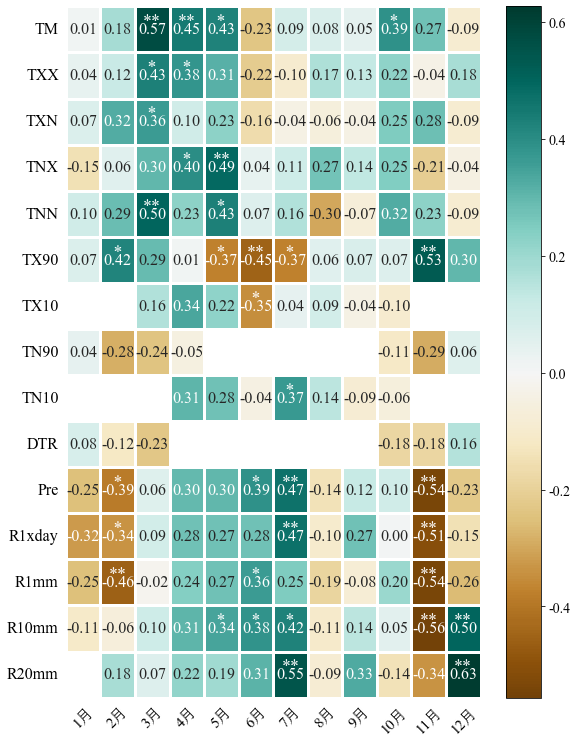

In [2]:
correlation_path = 'G:/tudi_ndvi/month/output/month_correlation.npz'

fig=plt.figure(figsize=(10,8))
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

font = {'weight': 'bold','size': 16}

correlation = np.load(correlation_path)
indices_month_r = correlation['indices_month_r']
indices_month_p = correlation['indices_month_p']

#绘制热图
ax2 = fig.add_axes([0.1, 1.5, 0.6, 0.8])
ax2 = sns.heatmap(indices_month_r,cmap= 'BrBG',annot=True,center=0,linewidths=2.5,cbar=False,fmt=".2f")
cb2=ax2.figure.colorbar(ax2.collections[0],ax=ax2) 
cb2.ax.tick_params(labelsize=14) 
ax2.set_xticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5],('1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月'),fontsize = 15,rotation=45)
ax2.set_yticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5],('TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday', 'R1mm', 'R10mm', 'R20mm'),style='italic',fontsize = 16,rotation=0)
ax2.tick_params(axis='x', width=0)
ax2.tick_params(axis='y', width=0)
ax2.figure.set_size_inches(12,12)

for i in range(15):
    for j in range(12):
        if indices_month_p[i,j] < 0.01:
            if abs(indices_month_r[i,j]) >=0.30:
                plt.text(0.5+j, 0.5+i, '**', ha='center', va='bottom', fontsize=18,color='white') 
            else:
                plt.text(0.5+j, 0.5+i, '**', ha='center', va='bottom', fontsize=18,color='black') 
        if indices_month_p[i,j] < 0.05 and indices_month_p[i,j] >= 0.01:
            if abs(indices_month_r[i,j]) >=0.30:
                plt.text(0.5+j, 0.5+i, ' * ', ha='center', va='bottom', fontsize=18,color='white')
            else:
                plt.text(0.5+j, 0.5+i, '*', ha='center', va='bottom', fontsize=18,color='black')
            
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\month_co.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

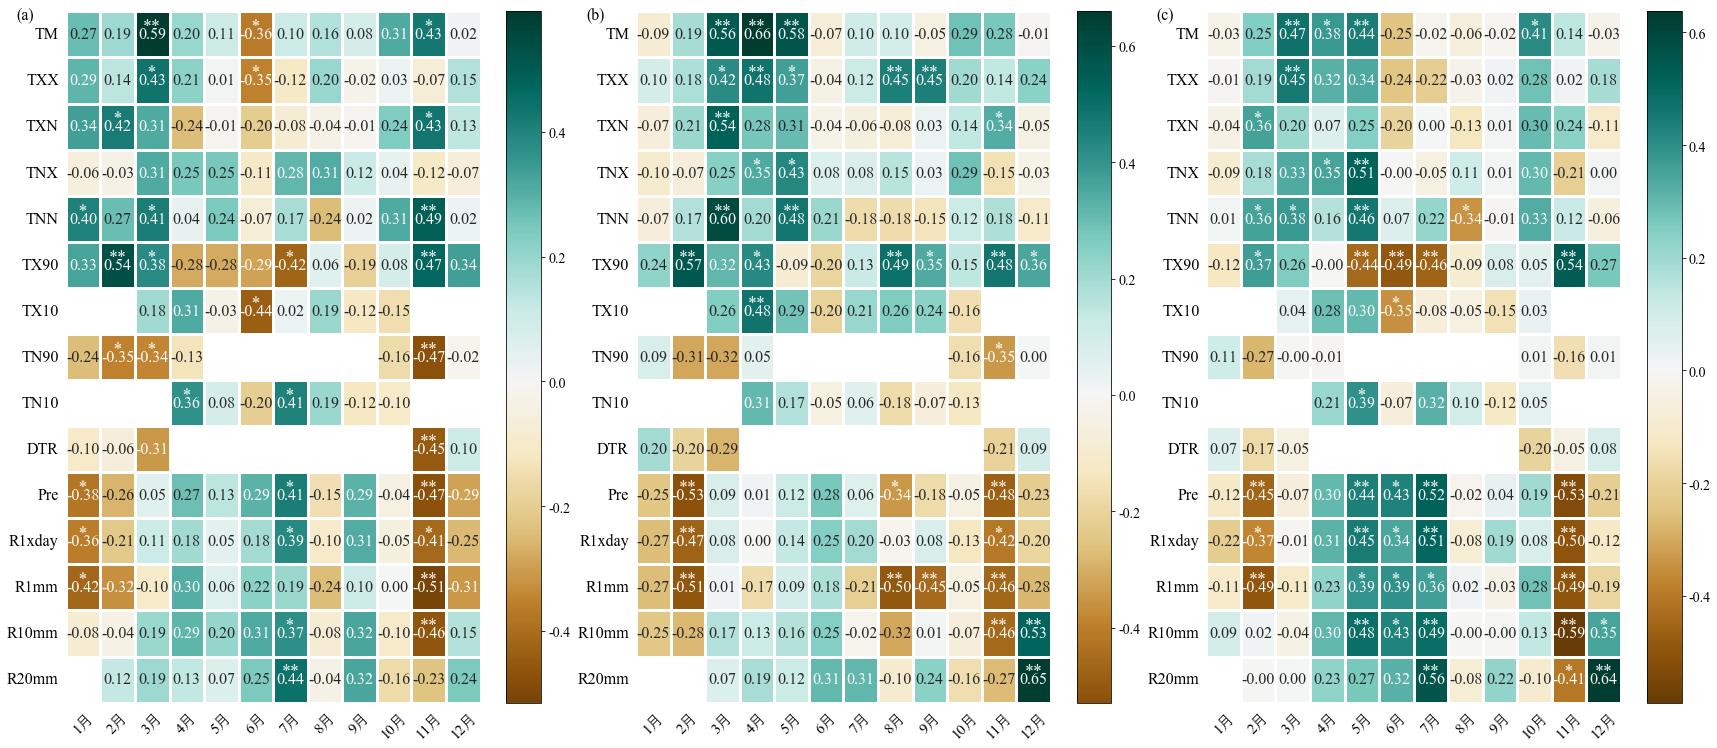

In [9]:
correlation_path = np.array(['G:/tudi_ndvi/month/output/1112_month_correlation.npz','G:/tudi_ndvi/month/output/2124_month_correlation.npz','G:/tudi_ndvi/month/output/3133_month_correlation.npz'])

title = np.array(['(a)','(b)','(c)'])

fig=plt.figure(figsize=(10,8))
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

font = {'weight': 'bold','size': 16}

for k in range(3):
    correlation = np.load(correlation_path[k])
    indices_month_r = correlation['indices_month_r']
    indices_month_p = correlation['indices_month_p']
    ax2 = fig.add_axes([0.1+0.66*k, 0.1, 0.6, 0.8])
    #绘制热图
    ax2 = sns.heatmap(indices_month_r,cmap= 'BrBG',annot=True,center=0,linewidths=2.5,cbar=False,fmt=".2f")
    cb2=ax2.figure.colorbar(ax2.collections[0],ax=ax2) 
    cb2.ax.tick_params(labelsize=14) 
    ax2.set_xticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5],('1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月'),fontsize = 15,rotation=45)
    ax2.set_yticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5],('TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday', 'R1mm', 'R10mm', 'R20mm'),style='italic',fontsize = 16,rotation=0)
    ax2.tick_params(axis='x', width=0)
    ax2.tick_params(axis='y', width=0)
    ax2.figure.set_size_inches(12,12)
    #设置标题
    ax2.text(-0.12, 0.99, '{}'.format(title[k]), transform=ax2.transAxes,fontdict=font)
    for i in range(15):
        for j in range(12):
            if indices_month_p[i,j] < 0.01:
                if abs(indices_month_r[i,j]) >=0.30:
                    plt.text(0.5+j, 0.5+i, '**', ha='center', va='bottom', fontsize=18,color='white') 
                else:
                    plt.text(0.5+j, 0.5+i, '**', ha='center', va='bottom', fontsize=18,color='black') 
            if indices_month_p[i,j] < 0.05 and indices_month_p[i,j] >= 0.01:
                if abs(indices_month_r[i,j]) >=0.30:
                    plt.text(0.5+j, 0.5+i, ' * ', ha='center', va='bottom', fontsize=18,color='white')
                else:
                    plt.text(0.5+j, 0.5+i, '*', ha='center', va='bottom', fontsize=18,color='black')
                    
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\veg_month_co.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

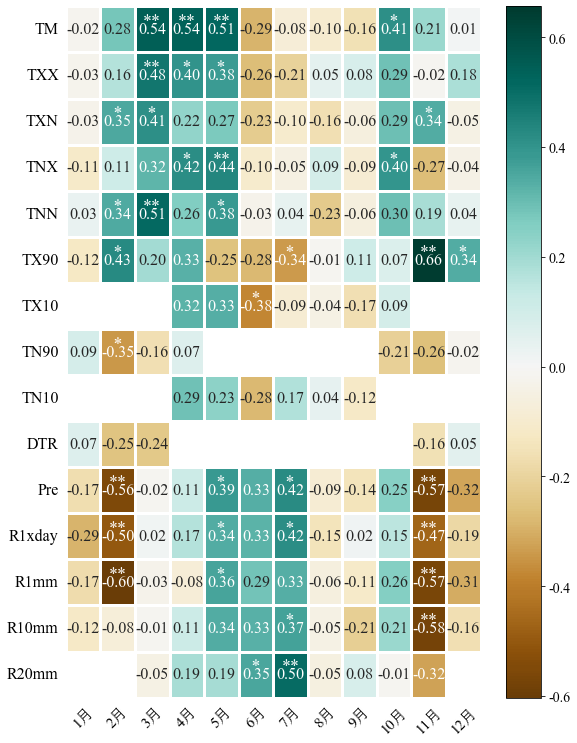

In [38]:
correlation_path = 'G:/reserve/month/output/month_correlation.npz'

fig=plt.figure(figsize=(10,8))
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

font = {'weight': 'bold','size': 16}

correlation = np.load(correlation_path)
indices_month_r = correlation['indices_month_r']
indices_month_p = correlation['indices_month_p']

#绘制热图
ax2 = fig.add_axes([0.1, 1.5, 0.6, 0.8])
ax2 = sns.heatmap(indices_month_r,cmap= 'BrBG',annot=True,center=0,linewidths=2.5,cbar=False,fmt=".2f")
cb2=ax2.figure.colorbar(ax2.collections[0],ax=ax2) 
cb2.ax.tick_params(labelsize=14) 
ax2.set_xticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5],('1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月'),fontsize = 15,rotation=45)
ax2.set_yticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5],('TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday', 'R1mm', 'R10mm', 'R20mm'),style='italic',fontsize = 16,rotation=0)
ax2.tick_params(axis='x', width=0)
ax2.tick_params(axis='y', width=0)
ax2.figure.set_size_inches(12,12)

for i in range(15):
    for j in range(12):
        if indices_month_p[i,j] < 0.01:
            if abs(indices_month_r[i,j]) >=0.30:
                plt.text(0.5+j, 0.5+i, '**', ha='center', va='bottom', fontsize=18,color='white') 
            else:
                plt.text(0.5+j, 0.5+i, '**', ha='center', va='bottom', fontsize=18,color='black') 
        if indices_month_p[i,j] < 0.05 and indices_month_p[i,j] >= 0.01:
            if abs(indices_month_r[i,j]) >=0.30:
                plt.text(0.5+j, 0.5+i, ' * ', ha='center', va='bottom', fontsize=18,color='white')
            else:
                plt.text(0.5+j, 0.5+i, '*', ha='center', va='bottom', fontsize=18,color='black')
            
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\reserve_month_co.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

## NDVI月尺度变化趋势

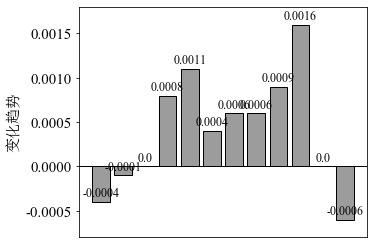

In [57]:
huabei = np.array([-0.0004,-0.0001,0,0.0008,0.0011,0.0004,0.0006,0.0006,0.0009,0.0016,0,-0.0006])
crop = np.array([-0.0003,-0.0001,0.0003,0.0013,0.0011,0.0005,0.0012,0.0013,0.0018,0.0026,0.0002,-0.0001])
forest = np.array([-0.0010,-0.0006,-0.0004,0.0013,0.0019,0.0004,0.0002,0.0001,0.0011,0.0025,0.0001,-0.0013])
grass = np.array([-0.0005,0,0,0.0005,0.0012,0.0005,0.0006,0.0006,0.0005,0.0012,-0.0001,-0.0007])

month = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
fig=plt.figure(figsize=(8,8))
plt.rcParams['font.size'] = 15 # 设置字体大小
ax1 = fig.add_axes([0.0,0.0,0.5,0.4])
#折线图
ax1.bar(month,huabei,color='#9C9C9C',width=0.8,align='center',edgecolor="k")
ax1.axhline(0, color='black', linewidth=1)
ax1.set_xticks([])
#加入xy轴标签
ax1.set_ylabel('变化趋势')
#加入标注
ax1.set_ylim(-0.0008,0.0018)
for a, b in zip(month, huabei):
    plt.text(a, b+0.00002, b, ha='center', va='bottom', fontsize=12,color='black')
    
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\ndvi_month_huabei.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

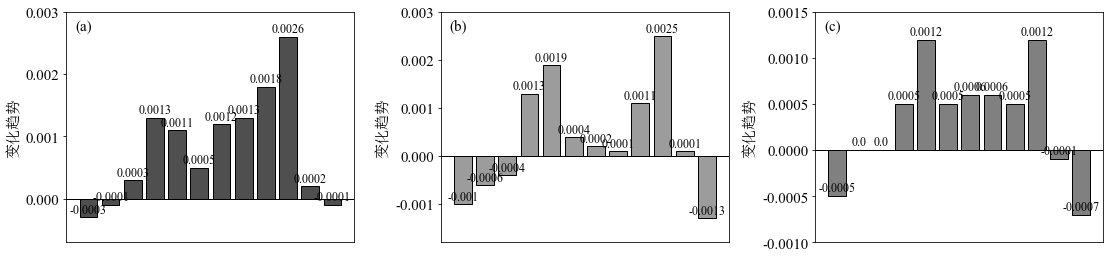

In [58]:
fig=plt.figure(figsize=(8,8))
data=[crop,forest,grass]

ax1 = fig.add_axes([0+0.65*0,0.0,0.5,0.4])
#折线图
ax1.bar(month,data[0],color='#4F4F4F',width=0.8,align='center',edgecolor="k")
ax1.axhline(0, color='black', linewidth=1)
ax1.set_xticks([])
#加入xy轴标签
ax1.set_ylabel('变化趋势')
#加入标注
for a, b in zip(month, data[0]):
    plt.text(a, b+0.00002, b, ha='center', va='bottom', fontsize=12,color='black')
ax1.set_ylim(-0.0007,0.0030)  
ax1.text(0.03, 0.92, '(a)',transform=ax1.transAxes)

ax1 = fig.add_axes([0+0.65*1,0.0,0.5,0.4])
#折线图
ax1.bar(month,data[1],color='#9C9C9C',width=0.8,align='center',edgecolor="k")
ax1.axhline(0, color='black', linewidth=1)
ax1.set_xticks([])
#加入xy轴标签
ax1.set_ylabel('变化趋势')
#加入标注
for a, b in zip(month, data[1]):
    plt.text(a, b+0.00002, b, ha='center', va='bottom', fontsize=12,color='black')
ax1.set_ylim(-0.0018,0.0030)  
ax1.text(0.03, 0.92, '(b)',transform=ax1.transAxes)

ax1 = fig.add_axes([0+0.65*2,0.0,0.5,0.4])
#折线图
ax1.bar(month,data[2],color='grey',width=0.8,align='center',edgecolor="k")
ax1.axhline(0, color='black', linewidth=1)
ax1.set_xticks([])
#加入xy轴标签
ax1.set_ylabel('变化趋势')
#加入标注
for a, b in zip(month, data[2]):
    plt.text(a, b+0.00002, b, ha='center', va='bottom', fontsize=12,color='black')
ax1.set_ylim(-0.001,0.0015)
ax1.text(0.03, 0.92, '(c)',transform=ax1.transAxes)

fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\veg_month_huabei.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

## 保护区ndvi变化

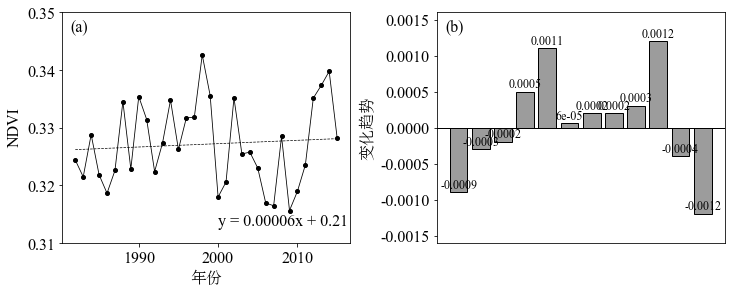

In [17]:
ndvi_mean = pd.read_csv('G:/reserve/output/ndvi_mean.csv')
ndvi_mean = ndvi_mean['NDVI']
ndvi_mean = np.array(ndvi_mean)
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号


#x轴年份
year = np.arange(1982,2016,1)
#求线性趋势
s1,d1,r1,p1,_ = linregress(year,ndvi_mean)
#设置图纸大小
fig=plt.figure(figsize=(8,8))
#第一个图的位置
ax1 = fig.add_axes([0.0,0.0,0.5,0.4])
#折线图
ax1.plot(year,ndvi_mean,lw=0.8,marker='o',color='k',ms='4')
#设置标题

#加入线性趋势
ax1.plot(year,s1*year+d1,'k--',lw=0.7)
#加入xy轴标签
ax1.set_xlabel('年份')
ax1.set_ylabel('NDVI')
#加入标注
ax1.text(2000,0.313,'y = 0.00006x + 0.21 ')
ax1.set_ylim(0.310,0.350)
ax1.text(0.03, 0.92, '(a)',transform=ax1.transAxes)

#第二个图位置
ax1 = fig.add_axes([0.65,0.0,0.5,0.4])
#折线图
month = np.array([1,2,3,4,5,6,7,8,9,10,11,12])
ndvi = np.array([-0.0009,-0.0003,-0.0002,0.0005,0.0011,0.00006,0.0002,0.0002,0.0003,0.0012,-0.0004,-0.0012])
ax1.bar(month,ndvi,color='#9C9C9C',width=0.8,align='center',edgecolor="k")
ax1.axhline(0, color='black', linewidth=1)
ax1.set_xticks([])
#加入xy轴标签
ax1.set_ylabel('变化趋势')
#加入标注
for a, b in zip(month, ndvi):
    plt.text(a, b+0.00002, b, ha='center', va='bottom', fontsize=12,color='black')
ax1.set_ylim(-0.0016,0.0016)  
ax1.text(0.03, 0.92, '(b)',transform=ax1.transAxes)

fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\reserve_ndvi.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

## 月尺度

In [9]:
correlation_path = 'G:/cn05/cn05_huabei/output/month_slope.csv'
correlation = pd.read_csv(correlation_path)
indices_month = np.array([correlation['Tm'],correlation['TXX'],correlation['TXN'], correlation['TNX'], correlation['TNN'], correlation['TX90'], correlation['TX10'], correlation['TN90'], correlation['TN10'], correlation['DTR'], correlation['pre'],correlation['R1xday'], correlation['R1mm'], correlation['R10mm'], correlation['R20mm']])
indices_month[:,0:12].shape

(15, 12)

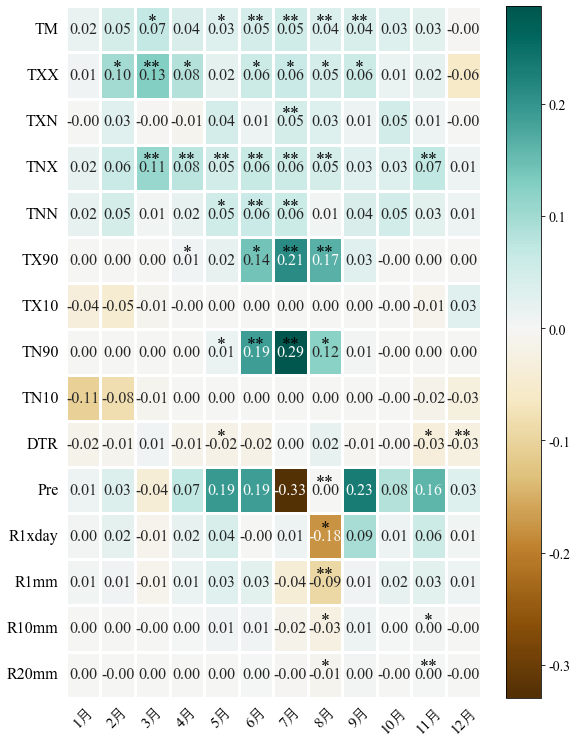

In [12]:
correlation_path = 'G:/cn05/cn05_huabei/output/month_slope.csv'

fig=plt.figure(figsize=(10,8))
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号


correlation = pd.read_csv(correlation_path)
indices_month = np.array([correlation['Tm'],correlation['TXX'],correlation['TXN'], correlation['TNX'], correlation['TNN'], correlation['TX90'], correlation['TX10'], correlation['TN90'], correlation['TN10'], correlation['DTR'], correlation['pre'],correlation['R1xday'], correlation['R1mm'], correlation['R10mm'], correlation['R20mm']])
indices_month_r = indices_month[:,0:12]
indices_month_p = indices_month[:,12:24]

#绘制热图
ax2 = fig.add_axes([0.1, 1.5, 0.6, 0.8])
ax2 = sns.heatmap(indices_month_r,cmap= 'BrBG',annot=True,center=0,linewidths=2.5,cbar=False,fmt=".2f")
cb2=ax2.figure.colorbar(ax2.collections[0],ax=ax2) 
cb2.ax.tick_params(labelsize=14) 
ax2.set_xticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5],('1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月'),fontsize = 15,rotation=45)
ax2.set_yticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5],('TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday', 'R1mm', 'R10mm', 'R20mm'),style='italic',fontsize = 16,rotation=0)
ax2.tick_params(axis='x', width=0)
ax2.tick_params(axis='y', width=0)
ax2.figure.set_size_inches(12,12)

for i in range(15):
    for j in range(12):
        if indices_month_p[i,j] < 0.01:
            if abs(indices_month_r[i,j]) >=0.30:
                plt.text(0.5+j, 0.5+i, '**', ha='center', va='bottom', fontsize=18,color='white') 
            else:
                plt.text(0.5+j, 0.5+i, '**', ha='center', va='bottom', fontsize=18,color='black') 
        if indices_month_p[i,j] < 0.05 and indices_month_p[i,j] >= 0.01:
            if abs(indices_month_r[i,j]) >=0.30:
                plt.text(0.5+j, 0.5+i, ' * ', ha='center', va='bottom', fontsize=18,color='white')
            else:
                plt.text(0.5+j, 0.5+i, '*', ha='center', va='bottom', fontsize=18,color='black')
            

## 保护区月变化

## 相关性分析

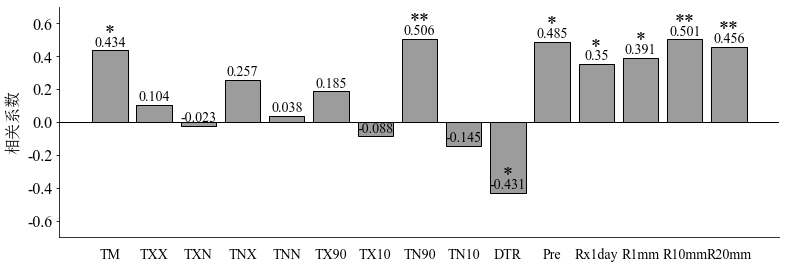

In [58]:
corre = np.array([0.434,0.104,-0.023,0.257,0.038,0.185,-0.088,0.506,-0.145,-0.431,0.485,0.35,0.391,0.501,0.456])
p_value = np.array([0.05,1,1,1,1,1,1,0.01,1,0.05,0.05,0.05,0.05,0.01,0.01])

font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
#print(prop.get_name())  # 显示当前使用字体的名称
#'Times New Roman + SimSun'sans-serif
#plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

fig=plt.figure(figsize=(10,8))
ax = fig.add_axes([0.0, 0, 1.0, 0.4])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.spines['left'].set_visible(False)
ax.axhline(y=0,c='k',lw=1.0)

ax.set_ylabel('相关系数',fontsize=16)
ax.set_ylim(-0.7,0.7)
#ax.set_xlim(0,30.3)
ax.set_xticks([])
#ax.set_yticks([0.2,0.4,0.6,0.8,1.0])

x1 = np.arange(1,16,1)

bar1 = ax.bar(x1,corre,color='#9C9C9C',width=0.8,align='center',edgecolor="k")

for i in range(15):
    if p_value[i]==0.01:
        plt.text(x1[i], corre[i]+0.05, '**', ha='center', va='bottom', fontsize=20,color='black') 
    if p_value[i]==0.05:
        plt.text(x1[i], corre[i]+0.05, ' * ', ha='center', va='bottom', fontsize=20,color='black')
    plt.text(x1[i], corre[i]+0.008, corre[i], ha='center', va='bottom', fontsize=14,color='black') 
    plt.text(x1[i], -0.85, ['TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','Rx1day','R1mm','R10mm','R20mm'][i], ha='center', va='bottom', fontsize=14,color='black') 
    
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\huabei_co.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

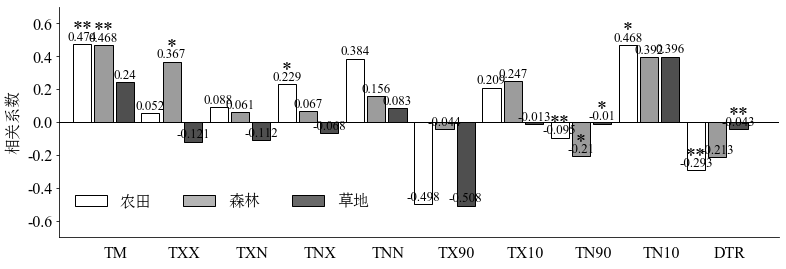

In [105]:

corre = np.array([[0.474,0.468,0.24],
                 [0.052,0.367,-0.121],
                 [0.088,0.061,-0.112],
                 [0.229,0.067,-0.068],
                 [0.384,0.156,0.083],
                 [-0.498,-0.044,-0.508],
                 [0.209,0.247,-0.013],
                 [-0.095,-0.210,-0.010],
                 [0.468,0.392,0.396],
                 [-0.293,-0.213,-0.043],
                 [0.301,0.189,0.630],
                 [-0.036,0.131,0.542],
                 [0.239,0.083,0.519],
                 [0.371,0.197,0.636],
                 [0.258,0.200,0.560]])


p_value = np.array([[0.01,0.01,1],
                    [1,0.05,1],
                    [1,1,1],
                    [0.05,1,1],
                    [1,1,1],
                    [1,1,1],
                    [1,1,1],
                    [0.01,0.05,0.05],
                    [0.05,1,1],
                    [0.01,1,0.01],
                    [1,1,0.01],
                    [1,1,0.01],
                    [1,1,0.01],
                    [0.05,1,0.01],
                    [1,1,0.01]])

fig=plt.figure(figsize=(10,8))
ax = fig.add_axes([0.0, 0, 1.0, 0.4])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])
ax.axhline(y=0,c='k',lw=1.0)

ax.set_ylabel('相关系数',fontsize=16)
ax.set_ylim(-0.7,0.7)
ax.set_xlim(-0.5,47)
#ax.set_xticks((6.3,12.3,18.3,24.3,30.3),['','','','',''])
#ax.set_yticks([0.2,0.4,0.6,0.8,1.0])

x1 = np.arange(1,45,4.5)
x2 = np.arange(2.4,47.4,4.5)
x3 = np.arange(3.8,48.8,4.5)
x = [x1,x2,x3]
bar1 = ax.bar(x1,(corre[:,0][0:10]),color='white',width=1.2,align='center',edgecolor="k")
bar2 = ax.bar(x2,(corre[:,1][0:10]),color='#9C9C9C',width=1.2,align='center',edgecolor="k")
bar3 = ax.bar(x3,(corre[:,2][0:10]),color='#4F4F4F',width=1.2,align='center',edgecolor="k")


#设置图例分别对应三个颜色
patchs = [mpatches.Patch(facecolor='white', label='农田',edgecolor='k'),mpatches.Patch(facecolor='#B5B5B5', label='森林',edgecolor='k'),mpatches.Patch(facecolor='#696969', label='草地',edgecolor='k')]
#添加图例
fig.legend(handles=patchs,frameon=False,prop = {'size':16}, bbox_to_anchor=(0.45,0.1),ncol = 3)

for i in range(10):
    for j in range(3):
        if p_value[i,j]==0.01:
            plt.text(x[j][i], corre[i,j]+0.03, '**', ha='center', va='bottom', fontsize=20,color='black') 
        if p_value[i,j]==0.05:
            plt.text(x[j][i], corre[i,j]+0.03, ' * ', ha='center', va='bottom', fontsize=20,color='black')
        if p_value[i,j]==1:
            plt.text(x[j][i], corre[i,j]+0.03, ' ', ha='center', va='bottom', fontsize=12,color='black')    
        plt.text(x[j][i], corre[i,j]+0.005, corre[i,j], ha='center', va='bottom', fontsize=13,color='black') 
    plt.text(x[0][i]+2.2, -0.85, ['TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','Rx1day','R1mm','R10mm','R20mm'][i], ha='center', va='bottom', fontsize=16,color='black') 

fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\veg_co_tem.pdf',format='pdf',dpi=600,bbox_inches = 'tight')


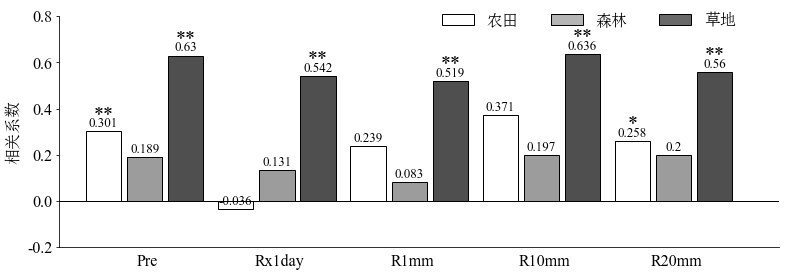

In [27]:

corre = np.array([[0.474,0.468,0.24],
                 [0.052,0.367,-0.121],
                 [0.088,0.061,-0.112],
                 [0.229,0.067,-0.068],
                 [0.384,0.156,0.083],
                 [-0.498,-0.044,-0.508],
                 [0.209,0.247,-0.013],
                 [-0.095,-0.210,-0.010],
                 [0.468,0.392,0.396],
                 [-0.293,-0.213,-0.043],
                 [0.301,0.189,0.630],
                 [-0.036,0.131,0.542],
                 [0.239,0.083,0.519],
                 [0.371,0.197,0.636],
                 [0.258,0.200,0.560]])


p_value = np.array([[0.01,0.01,1],
                    [1,0.05,1],
                    [1,1,1],
                    [0.05,1,1],
                    [1,1,1],
                    [1,1,1],
                    [1,1,1],
                    [0.01,0.05,0.05],
                    [0.05,1,1],
                    [0.01,1,0.01],
                    [1,1,0.01],
                    [1,1,0.01],
                    [1,1,0.01],
                    [0.05,1,0.01],
                    [1,1,0.01]])
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
#print(prop.get_name())  # 显示当前使用字体的名称
#'Times New Roman + SimSun'sans-serif
#plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

fig=plt.figure(figsize=(10,8))
ax = fig.add_axes([0.0, 0, 1.0, 0.4])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])
ax.axhline(y=0,c='k',lw=1.0)

ax.set_ylabel('相关系数',fontsize=16)
ax.set_ylim(-0.2,0.8)
ax.set_xlim(-0.5,24)

x1 = np.arange(1,23.5,4.5)
x2 = np.arange(2.4,23.5,4.5)
x3 = np.arange(3.8,23.5,4.5)
x = [x1,x2,x3]
bar1 = ax.bar(x1,(corre[:,0][10:15]),color='white',width=1.2,align='center',edgecolor="k")
bar2 = ax.bar(x2,(corre[:,1][10:15]),color='#9C9C9C',width=1.2,align='center',edgecolor="k")
bar3 = ax.bar(x3,(corre[:,2][10:15]),color='#4F4F4F',width=1.2,align='center',edgecolor="k")

#设置图例分别对应三个颜色
patchs = [mpatches.Patch(facecolor='white', label='农田',edgecolor='k'),mpatches.Patch(facecolor='#B5B5B5', label='森林',edgecolor='k'),mpatches.Patch(facecolor='#696969', label='草地',edgecolor='k')]
#添加图例
fig.legend(handles=patchs,frameon=False,prop = {'size':16}, bbox_to_anchor=(0.96,0.43),ncol = 3)

for i in range(5):
    for j in range(3):
        if p_value[9+i,j]==0.01:
            plt.text(x[j][i], corre[10+i,j]+0.03, '**', ha='center', va='bottom', fontsize=20,color='black') 
        if p_value[9+i,j]==0.05:
            plt.text(x[j][i], corre[10+i,j]+0.03, ' * ', ha='center', va='bottom', fontsize=20,color='black')
        if p_value[9+i,j]==1:
            plt.text(x[j][i], corre[10+i,j]+0.03, ' ', ha='center', va='bottom', fontsize=12,color='black')    
        plt.text(x[j][i], corre[10+i,j]+0.005, corre[10+i,j], ha='center', va='bottom', fontsize=13,color='black') 
    plt.text(x[0][i]+1.5, -0.3, ['Pre','Rx1day','R1mm','R10mm','R20mm'][i], ha='center', va='bottom', fontsize=16,color='black') 

fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\veg_co_pre.pdf',format='pdf',dpi=600,bbox_inches = 'tight')


## 保护区内月相关

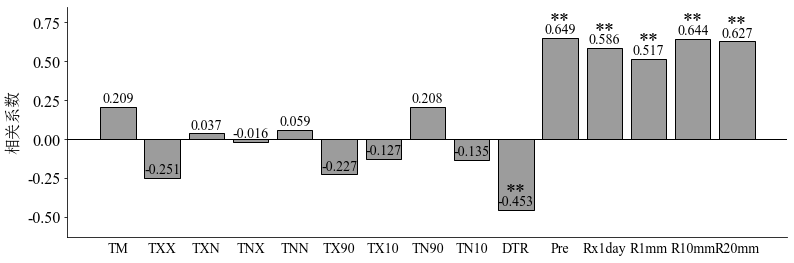

In [35]:
corre = np.array([0.209,-0.251,0.037,-0.016,0.059,-0.227,-0.127,0.208,-0.135,-0.453,0.649,0.586,0.517,0.644,0.627 
])
p_value = np.array([1,1,1,1,1,1,1,1,1,0.01,0.01,0.01,0.01,0.01,0.01])

font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
#print(prop.get_name())  # 显示当前使用字体的名称
#'Times New Roman + SimSun'sans-serif
#plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

fig=plt.figure(figsize=(10,8))
ax = fig.add_axes([0.0, 0, 1.0, 0.4])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.spines['left'].set_visible(False)
ax.axhline(y=0,c='k',lw=1.0)

ax.set_ylabel('相关系数',fontsize=16)
ax.set_ylim(-0.63,0.85)
#ax.set_xlim(0,30.3)
ax.set_xticks([])
#ax.set_yticks([0.2,0.4,0.6,0.8,1.0])

x1 = np.arange(1,16,1)

bar1 = ax.bar(x1,corre,color='#9C9C9C',width=0.8,align='center',edgecolor="k")

for i in range(15):
    if p_value[i]==0.01:
        plt.text(x1[i], corre[i]+0.05, '**', ha='center', va='bottom', fontsize=20,color='black') 
    if p_value[i]==0.05:
        plt.text(x1[i], corre[i]+0.05, ' * ', ha='center', va='bottom', fontsize=20,color='black')
    plt.text(x1[i], corre[i]+0.008, corre[i], ha='center', va='bottom', fontsize=14,color='black') 
    plt.text(x1[i], -0.75, ['TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','Rx1day','R1mm','R10mm','R20mm'][i], ha='center', va='bottom', fontsize=14,color='black') 
    
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\reserve_co.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

## 不同植被指数变化

In [77]:
data = ['G:/tudi_ndvi/output/1112_mean.csv','G:/tudi_ndvi/output/2124_mean.csv','G:/tudi_ndvi/output/3133_mean.csv']

for j in range(3):
    indices_mean = pd.read_csv(data[j])
    tm_mean = np.array(indices_mean['Tm'])
    txx_mean = np.array(indices_mean['TXX'])
    tnx_mean = np.array(indices_mean['TNX'])
    txn_mean = np.array(indices_mean['TXN'])
    tnn_mean = np.array(indices_mean['TNN'])
    tx90_mean = np.array(indices_mean['TX90'])
    tn90_mean = np.array(indices_mean['TN90'])
    tx10_mean = np.array(indices_mean['TX10'])
    tn10_mean = np.array(indices_mean['TN10'])
    dtr_mean = np.array(indices_mean['DTR'])
    pre_mean = np.array(indices_mean['Pre'])
    r1xday_mean = np.array(indices_mean['R1xday'])
    r1mm_mean = np.array(indices_mean['R1mm'])
    r10mm_mean = np.array(indices_mean['R10mm'])
    r20mm_mean = np.array(indices_mean['R20mm'])
    slope_mean = np.array([tm_mean,txx_mean,txn_mean,tnx_mean,tnn_mean,tx90_mean,tx10_mean,tn90_mean,tn10_mean,dtr_mean,pre_mean,r1xday_mean,r1mm_mean,r10mm_mean,r20mm_mean])
    s = np.full((15),fill_value=np.nan)
    p = np.full((15),fill_value=np.nan)
    for i in range(15):
        s[i],_,_,p[i],_ = linregress(year,slope_mean[i])
    print(s)
    print(p)

[ 3.43817846e-02  4.68738125e-02  9.61851486e-03  4.97734242e-02
  3.68656800e-02  4.83999850e-01 -9.60390975e-02  5.65522345e-01
 -4.31159964e-01 -1.69304299e-02 -1.85064672e+02 -1.84984551e-01
 -5.18320199e-03 -4.94512991e-04 -9.97455625e-03]
[2.84887313e-04 1.64295934e-02 7.78153687e-01 1.77125792e-04
 2.35194962e-01 1.70986305e-03 6.43245672e-01 9.71802051e-05
 2.92529438e-02 5.28900564e-04 6.72516783e-01 1.16201649e-01
 9.56731978e-01 9.88037985e-01 5.62481494e-01]
[ 3.00829091e-02  7.09035661e-02  1.64937698e-03  4.56652557e-02
  2.08991259e-02  6.13108066e-01 -3.90287632e-02  4.83678961e-01
 -1.37466363e-01 -4.88849088e-03 -2.57273993e+02 -2.41058577e-02
  6.46513377e-04 -2.54260056e-02 -7.76701684e-03]
[2.51935863e-03 2.75333983e-03 9.65262586e-01 2.73136040e-03
 5.30719235e-01 2.26664183e-04 8.56605946e-01 3.58383259e-05
 5.09494875e-01 3.62008946e-01 6.12944775e-01 7.78114421e-01
 9.95151554e-01 5.48313025e-01 6.36328204e-01]
[ 3.76769837e-02  6.04716702e-02  3.86846323e-04  

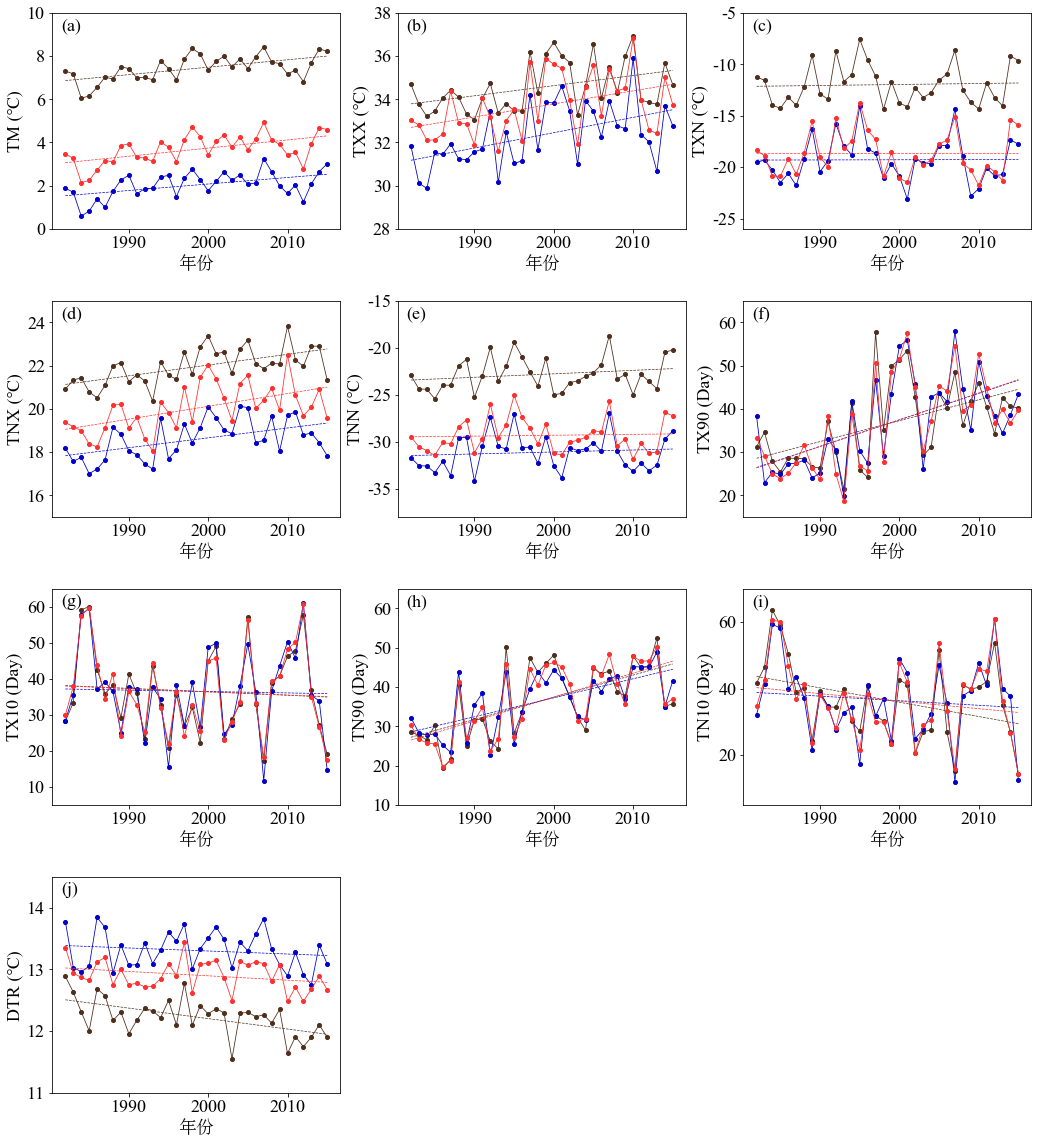

In [53]:
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
#print(prop.get_name())  # 显示当前使用字体的名称

plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 18 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

data = ['G:/tudi_ndvi/output/1112_mean.csv','G:/tudi_ndvi/output/2124_mean.csv','G:/tudi_ndvi/output/3133_mean.csv']

indices_mean  = pd.read_csv('G:/tudi_ndvi/output/1112_mean.csv')
indices_mean  = pd.read_csv('G:/tudi_ndvi/output/2124_mean.csv')
indices_mean  = pd.read_csv('G:/tudi_ndvi/output/3133_mean.csv')
#x轴年份
year = np.arange(1982,2016,1)
fig=plt.figure(figsize=(10,10))
ax1 = fig.add_axes([0, 0, 0.4, 0.3])
ax1.set_xlabel('年份')
ax1.set_ylabel('TM (℃)')
ax1.text(0.03, 0.92, '(a)',transform=ax1.transAxes)
ax1.set_ylim(0,10)

ax2 = fig.add_axes([0.48, 0, 0.4, 0.3])
ax2.set_xlabel('年份')
ax2.set_ylabel('TXX (℃)')
ax2.text(0.03, 0.92, '(b)',transform=ax2.transAxes)
ax2.set_ylim(28,38)

ax3 = fig.add_axes([0.96, 0, 0.4, 0.3])
ax3.set_xlabel('年份')
ax3.set_ylabel('TXN (℃)')
ax3.text(0.03, 0.92,'(c)',transform=ax3.transAxes)
ax3.set_ylim(-26,-5)


ax4 = fig.add_axes([0.0, -0.4, 0.4, 0.3])
ax4.set_xlabel('年份')
ax4.set_ylabel('TNX (℃)')
ax4.text(0.03, 0.92,'(d)',transform=ax4.transAxes)
ax4.set_ylim(15,25)

ax5 = fig.add_axes([0.48, -0.4, 0.4, 0.3])
ax5.set_xlabel('年份')
ax5.set_ylabel('TNN (℃)')
ax5.text(0.03, 0.92,'(e)',transform=ax5.transAxes)
ax5.set_ylim(-38,-15)

ax6 = fig.add_axes([0.96, -0.4, 0.4, 0.3])
ax6.text(0.03, 0.92,'(f)',transform=ax6.transAxes)
ax6.set_xlabel('年份')
ax6.set_ylabel('TX90 (Day)')
ax6.set_ylim(15,65)

ax7 = fig.add_axes([0.0, -0.8, 0.4, 0.3])
ax7.set_xlabel('年份')
ax7.set_ylabel('TX10 (Day)')
ax7.text(0.03, 0.92,'(g)',transform=ax7.transAxes)
ax7.set_ylim(5,65)

ax8 = fig.add_axes([0.48, -0.8, 0.4, 0.3])
ax8.set_xlabel('年份')
ax8.set_ylabel('TN90 (Day)')
ax8.text(0.03, 0.92,'(h)',transform=ax8.transAxes)
ax8.set_ylim(10,65)

ax9 = fig.add_axes([0.96, -0.8, 0.4, 0.3])
ax9.set_xlabel('年份')
ax9.set_ylabel('TN10 (Day)')
ax9.text(0.03, 0.92,'(i)',transform=ax9.transAxes)
ax9.set_ylim(5,70)

ax10 = fig.add_axes([0.0, -1.2, 0.4, 0.3])
ax10.set_xlabel('年份')
ax10.set_ylabel('DTR (℃)')
ax10.text(0.03, 0.92,'(j)',transform=ax10.transAxes)
ax10.set_ylim(11,14.5)

color = ['#4f2e1c','#0000CD','#FF3030']
for j in range(3):
    indices_mean = pd.read_csv(data[j])
    tm_mean = np.array(indices_mean['Tm'])
    txx_mean = np.array(indices_mean['TXX'])
    tnx_mean = np.array(indices_mean['TNX'])
    txn_mean = np.array(indices_mean['TXN'])
    tnn_mean = np.array(indices_mean['TNN'])
    tx90_mean = np.array(indices_mean['TX90'])
    tn90_mean = np.array(indices_mean['TN90'])
    tx10_mean = np.array(indices_mean['TX10'])
    tn10_mean = np.array(indices_mean['TN10'])
    dtr_mean = np.array(indices_mean['DTR'])
    pre_mean = np.array(indices_mean['Pre'])
    r1xday_mean = np.array(indices_mean['R1xday'])
    r1mm_mean = np.array(indices_mean['R1mm'])
    r10mm_mean = np.array(indices_mean['R10mm'])
    r20mm_mean = np.array(indices_mean['R20mm'])
    slope_mean = np.array([tm_mean,txx_mean,txn_mean,tnx_mean,tnn_mean,tx90_mean,tx10_mean,tn90_mean,tn10_mean,dtr_mean,pre_mean,r1xday_mean,r1mm_mean,r10mm_mean,r20mm_mean])
    s = np.full((15),fill_value=np.nan)
    d = np.full((15),fill_value=np.nan)
    p = np.full((15),fill_value=np.nan)
    r = np.full((15),fill_value=np.nan)
    for i in range(15):
        s[i],d[i],r[i],p[i],_ = linregress(year,slope_mean[i])
    ax1.plot(year,tm_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax1.plot(year,s[0]*year+d[0],'--',color=color[j],lw=0.7)
    ax2.plot(year,txx_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax2.plot(year,s[1]*year+d[1],'--',color=color[j],lw=0.7)
    ax3.plot(year,txn_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax3.plot(year,s[2]*year+d[2],'--',color=color[j],lw=0.7)
    ax4.plot(year,tnx_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax4.plot(year,s[3]*year+d[3],'--',color=color[j],lw=0.7)
    ax5.plot(year,tnn_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax5.plot(year,s[4]*year+d[4],'--',color=color[j],lw=0.7)
    ax6.plot(year,tx90_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax6.plot(year,s[5]*year+d[5],'--',color=color[j],lw=0.7)
    ax7.plot(year,tx10_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax7.plot(year,s[6]*year+d[6],'--',color=color[j],lw=0.7)
    ax8.plot(year,tn90_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax8.plot(year,s[7]*year+d[7],'--',color=color[j],lw=0.7)
    ax9.plot(year,tn10_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax9.plot(year,s[8]*year+d[8],'--',color=color[j],lw=0.7)
    ax10.plot(year,dtr_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax10.plot(year,s[9]*year+d[9],'--',color=color[j],lw=0.7)


#fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\veg_tem_Temporal.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

In [30]:
print(s,d,p,r)

[ 3.76769837e-02  6.04716702e-02  3.86846323e-04  5.91779275e-02
  9.39979406e-03  6.20363045e-01 -8.84950930e-02  6.08920762e-01
 -2.26383171e-01 -7.06414436e-03 -4.02632234e+02 -4.06759718e-02
 -1.79118035e-02 -1.30552808e-02 -6.66819588e-03] [-7.16160892e+01 -8.71602222e+01 -1.94610537e+01 -9.82403985e+01
 -4.81133169e+01 -1.20326613e+03  2.13386855e+02 -1.18039873e+03
  4.88956178e+02  2.70241578e+01  1.16248110e+06  1.09467911e+02
  9.52607854e+01  3.37836356e+01  1.52024822e+01] [5.61491020e-04 1.00946399e-02 9.91888550e-01 9.19868992e-04
 7.65664905e-01 2.21548988e-04 6.72978593e-01 1.24965713e-05
 2.83721703e-01 9.16701638e-02 6.27652046e-01 6.04005578e-01
 8.61874018e-01 6.27464530e-01 5.36146319e-01] [ 0.56075374  0.43523252  0.00181127  0.5424128   0.05306398  0.59264772
 -0.07508964  0.67387871 -0.189257   -0.29382442 -0.08625363 -0.09220661
 -0.03099095 -0.08630047 -0.10988589]


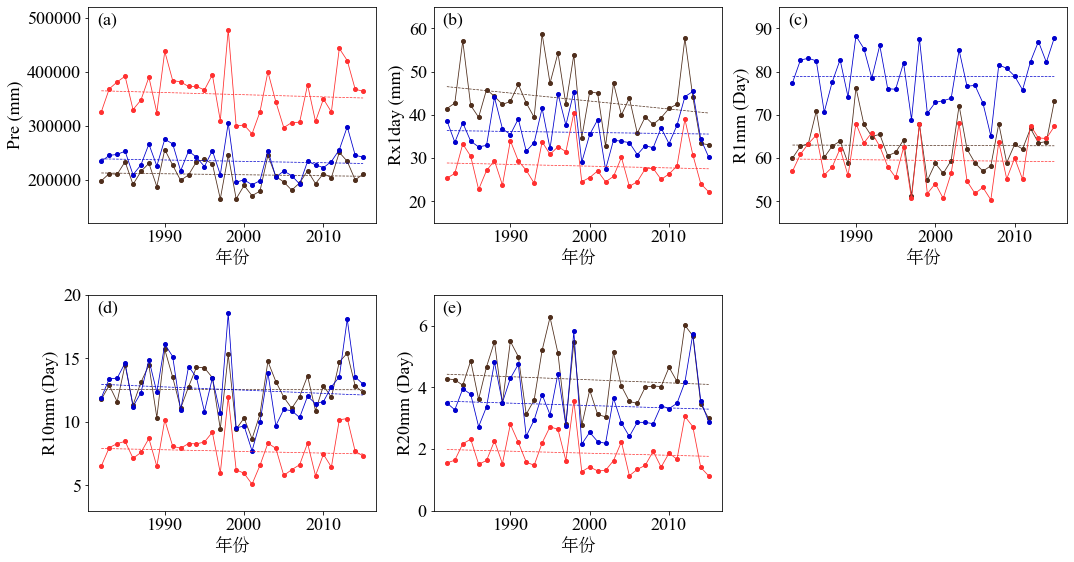

In [52]:
fig=plt.figure(figsize=(10,10))

ax11 = fig.add_axes([0, 0, 0.4, 0.3])
ax12 = fig.add_axes([0.48, 0, 0.4, 0.3])
ax13 = fig.add_axes([0.96, 0, 0.4, 0.3])
ax14 = fig.add_axes([0.0, -0.4, 0.4, 0.3])
ax15 = fig.add_axes([0.48, -0.4, 0.4, 0.3])

ax11.set_xlabel('年份')
ax11.set_ylabel('Pre (mm)')
ax11.text(0.03, 0.92, '(a)',transform=ax11.transAxes)
ax11.set_ylim(120000,520000)

ax12.set_xlabel('年份')
ax12.set_ylabel('Rx1day (mm)')
ax12.text(0.03, 0.92, '(b)',transform=ax12.transAxes)
ax12.set_ylim(15,65)

ax13.set_xlabel('年份')
ax13.set_ylabel('R1mm (Day)')
ax13.set_ylim(45,95)
ax13.text(0.03, 0.92, '(c)',transform=ax13.transAxes)

ax14.set_xlabel('年份')
ax14.set_ylabel('R10mm (Day)')
ax14.set_ylim(3,20)
ax14.text(0.03, 0.92, '(d)',transform=ax14.transAxes)

ax15.set_xlabel('年份')
ax15.set_ylabel('R20mm (Day)')
ax15.set_ylim(0,7)
ax15.text(0.03, 0.92, '(e)',transform=ax15.transAxes)

color = ['#4f2e1c','#0000CD','#FF3030']
for j in range(3):
    indices_mean = pd.read_csv(data[j])
    pre_mean = np.array(indices_mean['Pre'])
    r1xday_mean = np.array(indices_mean['R1xday'])
    r1mm_mean = np.array(indices_mean['R1mm'])
    r10mm_mean = np.array(indices_mean['R10mm'])
    r20mm_mean = np.array(indices_mean['R20mm'])
    slope_mean = np.array([tm_mean,txx_mean,txn_mean,tnx_mean,tnn_mean,tx90_mean,tx10_mean,tn90_mean,tn10_mean,dtr_mean,pre_mean,r1xday_mean,r1mm_mean,r10mm_mean,r20mm_mean])
    s = np.full((15),fill_value=np.nan)
    d = np.full((15),fill_value=np.nan)
    p = np.full((15),fill_value=np.nan)
    r = np.full((15),fill_value=np.nan)
    for i in range(15):
        s[i],d[i],r[i],p[i],_ = linregress(year,slope_mean[i])
    ax11.plot(year,pre_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax11.plot(year,s[10]*year+d[10],'--',color=color[j],lw=0.7)
    ax12.plot(year,r1xday_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax12.plot(year,s[11]*year+d[11],'--',color=color[j],lw=0.7)
    ax14.plot(year,r10mm_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax14.plot(year,s[13]*year+d[13],'--',color=color[j],lw=0.7)
    ax13.plot(year,r1mm_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax13.plot(year,s[12]*year+d[12],'--',color=color[j],lw=0.7)
    ax15.plot(year,r20mm_mean,lw=0.8,marker='o',color=color[j],ms='4')
    ax15.plot(year,s[14]*year+d[14],'--',color=color[j],lw=0.7)
    
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\veg_pre_Temporal.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

## 保护区内指数变化

In [79]:
print(s)

[ 3.29316376e-02  6.48504972e-02  4.98714445e-03  5.18441589e-02
  2.31102628e-03  6.57201372e-01 -4.48450173e-02  5.48357525e-01
 -1.33491540e-01 -9.04482429e-04 -6.93586916e+01 -7.18136306e-02
 -4.43200277e-02 -3.53932742e-02 -8.19856084e-03]


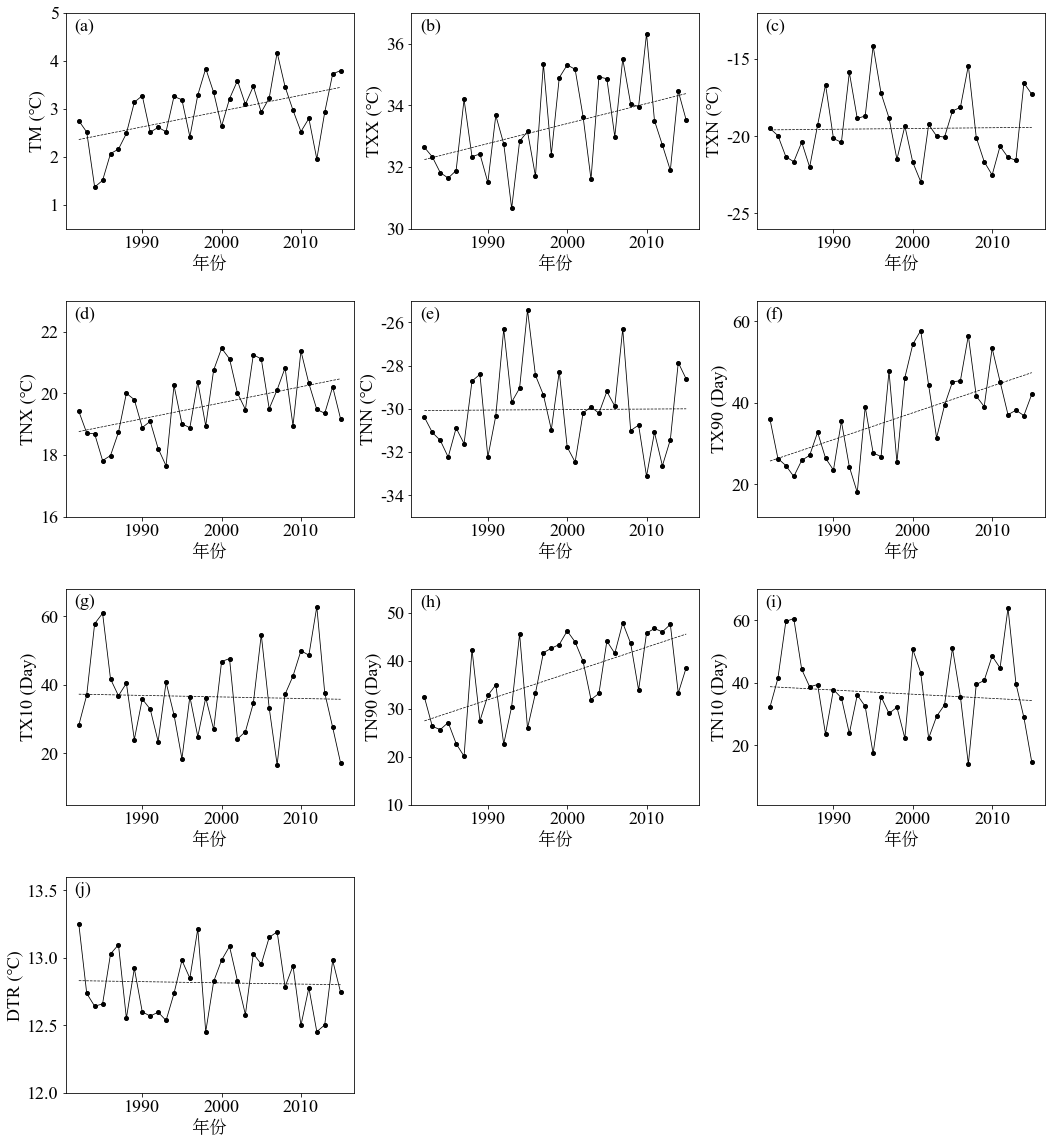

In [78]:
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
#print(prop.get_name())  # 显示当前使用字体的名称

plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 18 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

data = 'G:/reserve/output/indices_mean.csv'

#x轴年份
year = np.arange(1982,2016,1)
fig=plt.figure(figsize=(10,10))
ax1 = fig.add_axes([0, 0, 0.4, 0.3])
ax1.set_xlabel('年份')
ax1.set_ylabel('TM (℃)')
ax1.text(0.03, 0.92, '(a)',transform=ax1.transAxes)
ax1.set_ylim(0.5,5)

ax2 = fig.add_axes([0.48, 0, 0.4, 0.3])
ax2.set_xlabel('年份')
ax2.set_ylabel('TXX (℃)')
ax2.text(0.03, 0.92, '(b)',transform=ax2.transAxes)
ax2.set_ylim(30,37)

ax3 = fig.add_axes([0.96, 0, 0.4, 0.3])
ax3.set_xlabel('年份')
ax3.set_ylabel('TXN (℃)')
ax3.text(0.03, 0.92,'(c)',transform=ax3.transAxes)
ax3.set_ylim(-26,-12)


ax4 = fig.add_axes([0.0, -0.4, 0.4, 0.3])
ax4.set_xlabel('年份')
ax4.set_ylabel('TNX (℃)')
ax4.text(0.03, 0.92,'(d)',transform=ax4.transAxes)
ax4.set_ylim(16,23)

ax5 = fig.add_axes([0.48, -0.4, 0.4, 0.3])
ax5.set_xlabel('年份')
ax5.set_ylabel('TNN (℃)')
ax5.text(0.03, 0.92,'(e)',transform=ax5.transAxes)
ax5.set_ylim(-35,-25)

ax6 = fig.add_axes([0.96, -0.4, 0.4, 0.3])
ax6.text(0.03, 0.92,'(f)',transform=ax6.transAxes)
ax6.set_xlabel('年份')
ax6.set_ylabel('TX90 (Day)')
ax6.set_ylim(12,65)

ax7 = fig.add_axes([0.0, -0.8, 0.4, 0.3])
ax7.set_xlabel('年份')
ax7.set_ylabel('TX10 (Day)')
ax7.text(0.03, 0.92,'(g)',transform=ax7.transAxes)
ax7.set_ylim(5,68)

ax8 = fig.add_axes([0.48, -0.8, 0.4, 0.3])
ax8.set_xlabel('年份')
ax8.set_ylabel('TN90 (Day)')
ax8.text(0.03, 0.92,'(h)',transform=ax8.transAxes)
ax8.set_ylim(10,55)

ax9 = fig.add_axes([0.96, -0.8, 0.4, 0.3])
ax9.set_xlabel('年份')
ax9.set_ylabel('TN10 (Day)')
ax9.text(0.03, 0.92,'(i)',transform=ax9.transAxes)
ax9.set_ylim(1,70)

ax10 = fig.add_axes([0.0, -1.2, 0.4, 0.3])
ax10.set_xlabel('年份')
ax10.set_ylabel('DTR (℃)')
ax10.text(0.03, 0.92,'(j)',transform=ax10.transAxes)
ax10.set_ylim(12,13.6)


indices_mean = pd.read_csv(data)
tm_mean = np.array(indices_mean['TM'])
txx_mean = np.array(indices_mean['TXX'])
tnx_mean = np.array(indices_mean['TNX'])
txn_mean = np.array(indices_mean['TXN'])
tnn_mean = np.array(indices_mean['TNN'])
tx90_mean = np.array(indices_mean['TX90'])
tn90_mean = np.array(indices_mean['TN90'])
tx10_mean = np.array(indices_mean['TX10'])
tn10_mean = np.array(indices_mean['TN10'])
dtr_mean = np.array(indices_mean['DTR'])
pre_mean = np.array(indices_mean['Pre'])
r1xday_mean = np.array(indices_mean['R1xday'])
r1mm_mean = np.array(indices_mean['R1mm'])
r10mm_mean = np.array(indices_mean['R10mm'])
r20mm_mean = np.array(indices_mean['R20mm'])
slope_mean = np.array([tm_mean,txx_mean,txn_mean,tnx_mean,tnn_mean,tx90_mean,tx10_mean,tn90_mean,tn10_mean,dtr_mean,pre_mean,r1xday_mean,r1mm_mean,r10mm_mean,r20mm_mean])
s = np.full((15),fill_value=np.nan)
d = np.full((15),fill_value=np.nan)
p = np.full((15),fill_value=np.nan)
r = np.full((15),fill_value=np.nan)
for i in range(15):
    s[i],d[i],r[i],p[i],_ = linregress(year,slope_mean[i])
ax1.plot(year,tm_mean,lw=0.8,marker='o',color='k',ms='4')
ax1.plot(year,s[0]*year+d[0],'--',color='k',lw=0.7)
ax2.plot(year,txx_mean,lw=0.8,marker='o',color='k',ms='4')
ax2.plot(year,s[1]*year+d[1],'--',color='k',lw=0.7)
ax3.plot(year,txn_mean,lw=0.8,marker='o',color='k',ms='4')
ax3.plot(year,s[2]*year+d[2],'--',color='k',lw=0.7)
ax4.plot(year,tnx_mean,lw=0.8,marker='o',color='k',ms='4')
ax4.plot(year,s[3]*year+d[3],'--',color='k',lw=0.7)
ax5.plot(year,tnn_mean,lw=0.8,marker='o',color='k',ms='4')
ax5.plot(year,s[4]*year+d[4],'--',color='k',lw=0.7)
ax6.plot(year,tx90_mean,lw=0.8,marker='o',color='k',ms='4')
ax6.plot(year,s[5]*year+d[5],'--',color='k',lw=0.7)
ax7.plot(year,tx10_mean,lw=0.8,marker='o',color='k',ms='4')
ax7.plot(year,s[6]*year+d[6],'--',color='k',lw=0.7)
ax8.plot(year,tn90_mean,lw=0.8,marker='o',color='k',ms='4')
ax8.plot(year,s[7]*year+d[7],'--',color='k',lw=0.7)
ax9.plot(year,tn10_mean,lw=0.8,marker='o',color='k',ms='4')
ax9.plot(year,s[8]*year+d[8],'--',color='k',lw=0.7)
ax10.plot(year,dtr_mean,lw=0.8,marker='o',color='k',ms='4')
ax10.plot(year,s[9]*year+d[9],'--',color='k',lw=0.7)


#fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\reserve_tem_Temporal.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

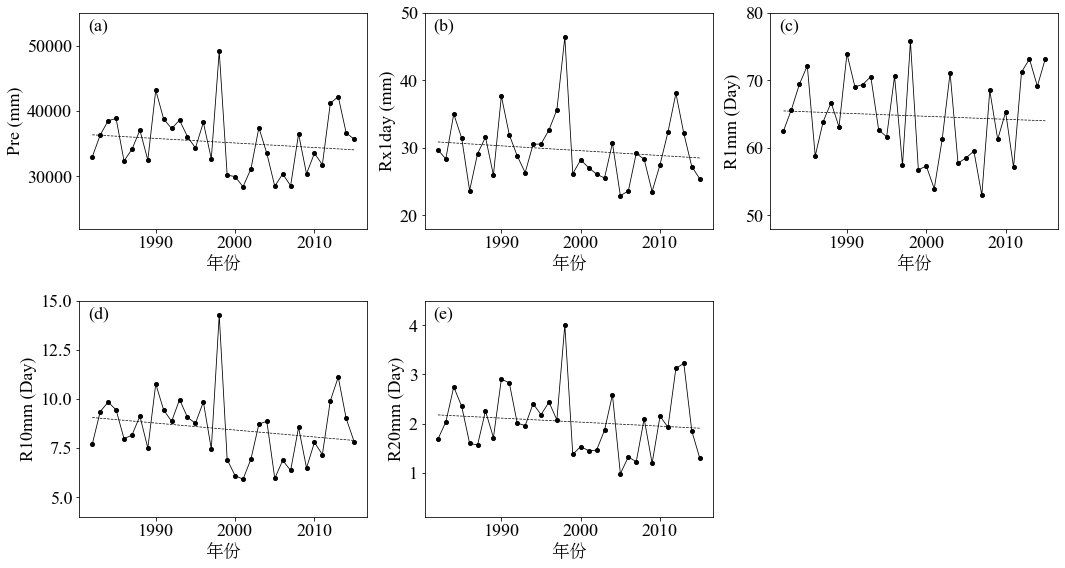

In [69]:
fig=plt.figure(figsize=(10,10))

ax11 = fig.add_axes([0, 0, 0.4, 0.3])
ax12 = fig.add_axes([0.48, 0, 0.4, 0.3])
ax13 = fig.add_axes([0.96, 0, 0.4, 0.3])
ax14 = fig.add_axes([0.0, -0.4, 0.4, 0.3])
ax15 = fig.add_axes([0.48, -0.4, 0.4, 0.3])

ax11.set_xlabel('年份')
ax11.set_ylabel('Pre (mm)')
ax11.text(0.03, 0.92, '(a)',transform=ax11.transAxes)
ax11.set_ylim(22000,55000)

ax12.set_xlabel('年份')
ax12.set_ylabel('Rx1day (mm)')
ax12.text(0.03, 0.92, '(b)',transform=ax12.transAxes)
ax12.set_ylim(18,50)

ax13.set_xlabel('年份')
ax13.set_ylabel('R1mm (Day)')
ax13.set_ylim(48,80)
ax13.text(0.03, 0.92, '(c)',transform=ax13.transAxes)

ax14.set_xlabel('年份')
ax14.set_ylabel('R10mm (Day)')
ax14.set_ylim(4,15)
ax14.text(0.03, 0.92, '(d)',transform=ax14.transAxes)

ax15.set_xlabel('年份')
ax15.set_ylabel('R20mm (Day)')
ax15.set_ylim(0.1,4.5)
ax15.text(0.03, 0.92, '(e)',transform=ax15.transAxes)

indices_mean = pd.read_csv(data)
pre_mean = np.array(indices_mean['Pre'])
r1xday_mean = np.array(indices_mean['R1xday'])
r1mm_mean = np.array(indices_mean['R1mm'])
r10mm_mean = np.array(indices_mean['R10mm'])
r20mm_mean = np.array(indices_mean['R20mm'])
slope_mean = np.array([tm_mean,txx_mean,txn_mean,tnx_mean,tnn_mean,tx90_mean,tx10_mean,tn90_mean,tn10_mean,dtr_mean,pre_mean,r1xday_mean,r1mm_mean,r10mm_mean,r20mm_mean])
s = np.full((15),fill_value=np.nan)
d = np.full((15),fill_value=np.nan)
p = np.full((15),fill_value=np.nan)
r = np.full((15),fill_value=np.nan)
for i in range(15):
    s[i],d[i],r[i],p[i],_ = linregress(year,slope_mean[i])
ax11.plot(year,pre_mean,lw=0.8,marker='o',color='k',ms='4')
ax11.plot(year,s[10]*year+d[10],'--',color='k',lw=0.7)
ax12.plot(year,r1xday_mean,lw=0.8,marker='o',color='k',ms='4')
ax12.plot(year,s[11]*year+d[11],'--',color='k',lw=0.7)
ax14.plot(year,r10mm_mean,lw=0.8,marker='o',color='k',ms='4')
ax14.plot(year,s[13]*year+d[13],'--',color='k',lw=0.7)
ax13.plot(year,r1mm_mean,lw=0.8,marker='o',color='k',ms='4')
ax13.plot(year,s[12]*year+d[12],'--',color='k',lw=0.7)
ax15.plot(year,r20mm_mean,lw=0.8,marker='o',color='k',ms='4')
ax15.plot(year,s[14]*year+d[14],'--',color='k',lw=0.7)
    
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\reserve_pre_Temporal.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

## 广义线性模型

In [2]:
from sklearn import linear_model
from sklearn.linear_model import Ridge,RidgeCV
from sklearn.linear_model import Lasso,LassoCV
from sklearn import model_selection
from sklearn.model_selection import GridSearchCV
from sklearn import preprocessing
import seaborn as sns
from sklearn import metrics

0.10653834747467816
[ 0.2523437   0.          0.          0.          0.          0.
 -0.          0.322008   -0.         -0.          0.41461671  0.
  0.          0.04660327  0.        ]
-2.3933014486109534e-15
0.7992400413343133 1.4474165844402009e-08


Text(0, 0.5, '预测NDVI')

c:\Users\86186\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\86186\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\86186\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\86186\anaconda3\lib\site-packages\IPython\core\pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


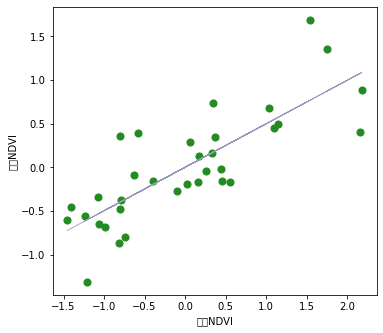

In [5]:
mean_mean = pd.read_csv('G:/cn05/cn05_huabei/output/mean_mean.csv')
indices_mean = pd.read_csv('G:/cn05/cn05_huabei/output/indices_mean.csv')
ndvi_mean = pd.read_csv('G:/cn05/cn05_huabei/output/ndvi_mean.csv')

indices_mean = np.array([mean_mean['tm'],indices_mean['TXX'],indices_mean['TXN'],indices_mean['TNN'],indices_mean['TNX'],indices_mean['TX90'],indices_mean['TX10'],indices_mean['TN90'],indices_mean['TN10'],indices_mean['DTR'],mean_mean['pre'],indices_mean['R1xday'],indices_mean['R1mm'],indices_mean['R10mm'],indices_mean['R20mm']])
indices_mean = np.transpose(indices_mean)
ndvi_mean = np.array(ndvi_mean['NDVI'])

indices_stan = np.full((34,15),fill_value=np.nan)

#标准化(按列)
for i in range(15):
    indices_stan[:,i] = preprocessing.scale(indices_mean[:,i])
#标准化
ndvi_stan = preprocessing.scale(ndvi_mean)

las= LassoCV(eps=0.1,n_alphas=100,fit_intercept=True,cv=20).fit(indices_stan,ndvi_stan)
print(las.alpha_ )
print(las.coef_)
print(las.intercept_)
ndvi_predict = las.predict(indices_stan)
r,p=pearsonr(ndvi_stan,ndvi_predict)
print(r,p)

s,d,r,p,_ = linregress(ndvi_stan,ndvi_predict)
fig=plt.figure(figsize=(10,10))
ax = fig.add_axes([0.0,0.0,0.45,0.4])
ax.scatter(ndvi_stan,ndvi_predict,c='#228B22',s=50)
ax.plot(ndvi_stan,ndvi_stan*s+d,lw=0.8,c='#9798b9')
ax.set_xlabel('原始NDVI')
ax.set_ylabel('预测NDVI')

#fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\huabei_glm.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

0.08419982293482155
[ 0.28490155 -0.          0.          0.12616904  0.10189866  0.
  0.          0.09180434  0.         -0.2096951   0.         -0.
  0.          0.27649819  0.        ]
-1.8515791218813774e-15
0.756067367534099 2.329527908009313e-07
0.09098896047995622
[ 0.27960537  0.42113672  0.         -0.         -0.          0.
 -0.          0.         -0.          0.          0.10516024  0.
  0.          0.22411932  0.08425081]
-1.9420041573675924e-16
0.7114929140523975 2.3910729127908173e-06
0.09051839834335611
[ 0.09105271  0.          0.          0.          0.          0.
 -0.          0.37348495 -0.         -0.          0.37101039  0.
  0.07348972  0.19061781  0.        ]
-7.75882356262658e-15
0.8270783789982558 1.645912901435864e-09


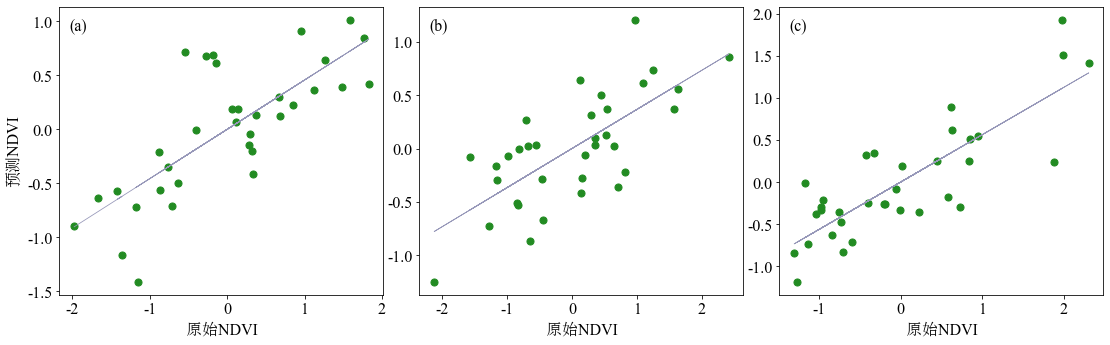

In [47]:
indices_data = pd.read_csv('G:/tudi_ndvi/output/1112_mean.csv')
ndvi_data = pd.read_csv('G:/tudi_ndvi/output/1112_ndvi_mean.csv')

indices_mean = np.array(indices_data[['Tm','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday','R1mm','R10mm','R20mm']])
ndvi_mean = np.array(ndvi_data['NDVI'])


font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
#print(prop.get_name())  # 显示当前使用字体的名称

plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号


indices_stan = np.full((34,15),fill_value=np.nan)

#标准化(按列)
for i in range(15):
    indices_stan[:,i] = preprocessing.scale(indices_mean[:,i])
#标准化
ndvi_stan = preprocessing.scale(ndvi_mean)

las= LassoCV(eps=0.1,n_alphas=1000,fit_intercept=True,cv=20).fit(indices_stan,ndvi_stan)
print(las.alpha_ )
print(las.coef_)
print(las.intercept_)
ndvi_predict = las.predict(indices_stan)
r,p=pearsonr(ndvi_stan,ndvi_predict)
print(r,p)

s,d,r,p,_ = linregress(ndvi_stan,ndvi_predict)
fig=plt.figure(figsize=(10,10))
ax = fig.add_axes([0.0,0.0,0.45,0.4])
ax.scatter(ndvi_stan,ndvi_predict,c='#228B22',s=50)
ax.plot(ndvi_stan,ndvi_stan*s+d,lw=0.8,c='#9798b9')
ax.set_xlabel('原始NDVI')
ax.set_ylabel('预测NDVI')
ax.text(0.03, 0.92, '(a)',transform=ax.transAxes)

#第二张图
indices_data = pd.read_csv('G:/tudi_ndvi/output/2124_mean.csv')
ndvi_data = pd.read_csv('G:/tudi_ndvi/output/2124_ndvi_mean.csv')
indices_mean = np.array(indices_data[['Tm','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday','R1mm','R10mm','R20mm']])
ndvi_mean = np.array(ndvi_data['NDVI'])
indices_stan = np.full((34,15),fill_value=np.nan)
#标准化(按列)
for i in range(15):
    indices_stan[:,i] = preprocessing.scale(indices_mean[:,i])
#标准化
ndvi_stan = preprocessing.scale(ndvi_mean)
las= LassoCV(eps=0.1,n_alphas=1000,fit_intercept=True,cv=20).fit(indices_stan,ndvi_stan)
print(las.alpha_ )
print(las.coef_)
print(las.intercept_)
ndvi_predict = las.predict(indices_stan)
r,p=pearsonr(ndvi_stan,ndvi_predict)
print(r,p)
s,d,r,p,_ = linregress(ndvi_stan,ndvi_predict)
ax = fig.add_axes([0.5,0.,0.45,0.4])
ax.scatter(ndvi_stan,ndvi_predict,c='#228B22',s=50)
ax.plot(ndvi_stan,ndvi_stan*s+d,lw=0.8,c='#9798b9')
ax.set_xlabel('原始NDVI')
ax.text(0.03, 0.92, '(b)',transform=ax.transAxes)

#第三张图
indices_data = pd.read_csv('G:/tudi_ndvi/output/3133_mean.csv')
ndvi_data = pd.read_csv('G:/tudi_ndvi/output/3133_ndvi_mean.csv')
indices_mean = np.array(indices_data[['Tm','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday','R1mm','R10mm','R20mm']])
ndvi_mean = np.array(ndvi_data['NDVI'])
indices_stan = np.full((34,15),fill_value=np.nan)
#标准化(按列)
for i in range(15):
    indices_stan[:,i] = preprocessing.scale(indices_mean[:,i])
#标准化
ndvi_stan = preprocessing.scale(ndvi_mean)
las= LassoCV(eps=0.1,n_alphas=1000,fit_intercept=True,cv=20).fit(indices_stan,ndvi_stan)
print(las.alpha_ )
print(las.coef_)
print(las.intercept_)
ndvi_predict = las.predict(indices_stan)
r,p=pearsonr(ndvi_stan,ndvi_predict)
print(r,p)
s,d,r,p,_ = linregress(ndvi_stan,ndvi_predict)
ax = fig.add_axes([1.0,0.0,0.45,0.4])
ax.scatter(ndvi_stan,ndvi_predict,c='#228B22',s=50)
ax.plot(ndvi_stan,ndvi_stan*s+d,lw=0.8,c='#9798b9')
ax.set_xlabel('原始NDVI')
ax.text(0.03, 0.92, '(c)',transform=ax.transAxes)

fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\veg_glm.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

0.08152921446939959
[ 0.0212793  -0.          0.          0.12772281  0.04023769 -0.
 -0.          0.12560424 -0.11661614 -0.          0.49268854  0.08354607
  0.          0.12893624  0.        ]
1.913839374865869e-16
0.7824075936450724 4.604529307118373e-08


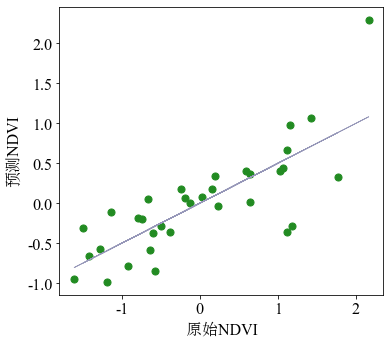

In [45]:

indices_mean = pd.read_csv('G:/reserve/output/indices_mean.csv')
ndvi_mean = pd.read_csv('G:/reserve/output/ndvi_mean.csv')

indices_mean = np.array(indices_mean[['TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday','R1mm','R10mm','R20mm']])
ndvi_mean = np.array(ndvi_mean['NDVI'])

indices_stan = np.full((34,15),fill_value=np.nan)

#标准化(按列)
for i in range(15):
    indices_stan[:,i] = preprocessing.scale(indices_mean[:,i])
#标准化
ndvi_stan = preprocessing.scale(ndvi_mean)

las= LassoCV(eps=0.1,n_alphas=1000,fit_intercept=True,cv=20).fit(indices_stan,ndvi_stan)
print(las.alpha_ )
print(las.coef_)
print(las.intercept_)
ndvi_predict = las.predict(indices_stan)
r,p=pearsonr(ndvi_stan,ndvi_predict)
print(r,p)

s,d,r,p,_ = linregress(ndvi_stan,ndvi_predict)
fig=plt.figure(figsize=(10,10))
ax = fig.add_axes([0.0,0.0,0.45,0.4])
ax.scatter(ndvi_stan,ndvi_predict,c='#228B22',s=50)
ax.plot(ndvi_stan,ndvi_stan*s+d,lw=0.8,c='#9798b9')
ax.set_xlabel('原始NDVI')
ax.set_ylabel('预测NDVI')

fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\reserve_glm.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

### 月尺度

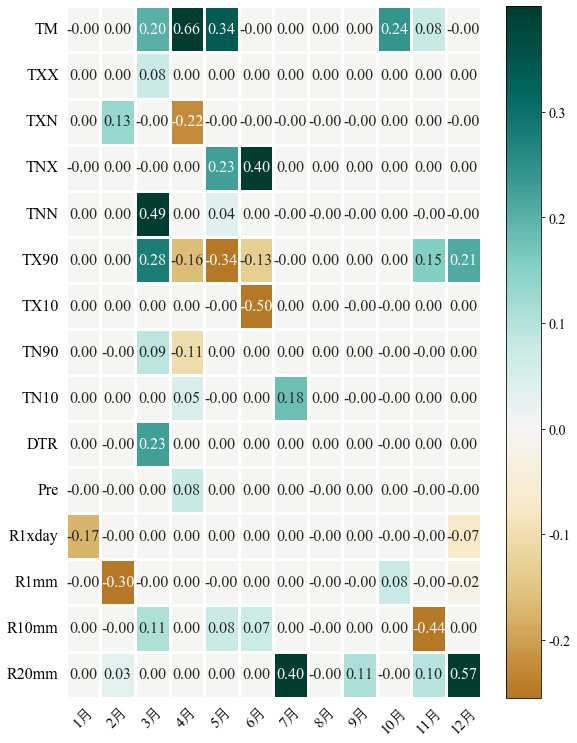

In [3]:
correlation_path = 'G:/cn05/cn05_huabei/output/huabei_month_glm.npz'

fig=plt.figure(figsize=(10,8))
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号


correlation = np.load(correlation_path)
indices_month_r = correlation['indices_coef']




#绘制热图
ax2 = fig.add_axes([0.1, 1.5, 0.6, 0.8])
ax2 = sns.heatmap(indices_month_r,cmap= 'BrBG',annot=True,center=0,linewidths=2.5,cbar=False,fmt=".2f",robust = True)
cb2=ax2.figure.colorbar(ax2.collections[0],ax=ax2) 
cb2.ax.tick_params(labelsize=14) 
ax2.set_xticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5],('1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月'),fontsize = 15,rotation=45)
ax2.set_yticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5],('TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday', 'R1mm', 'R10mm', 'R20mm'),style='italic',fontsize = 16,rotation=0)
ax2.tick_params(axis='x', width=0)
ax2.tick_params(axis='y', width=0)
ax2.figure.set_size_inches(12,12)

fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\huabei_month_glm.pdf',format='pdf',dpi=600,bbox_inches = 'tight')         

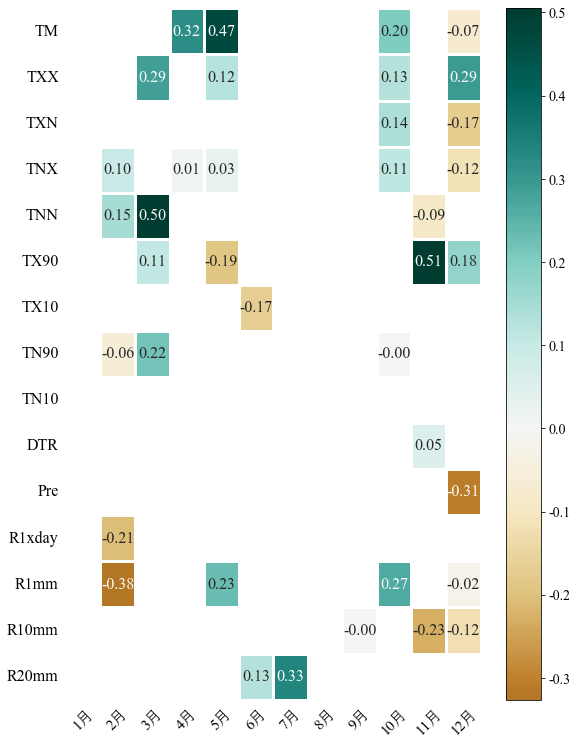

In [17]:
correlation_path = 'G:/reserve/month/output/reserve_month_glm.npz'

fig=plt.figure(figsize=(10,8))
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号


correlation = np.load(correlation_path)
indices_month_r = correlation['indices_coef']
indices_month_r[indices_month_r == 0] = np.nan 



#绘制热图
ax2 = fig.add_axes([0.1, 1.5, 0.6, 0.8])
ax2 = sns.heatmap(indices_month_r,cmap= 'BrBG',annot=True,center=0,linewidths=2.5,cbar=False,fmt=".2f",robust = True)
cb2=ax2.figure.colorbar(ax2.collections[0],ax=ax2) 
cb2.ax.tick_params(labelsize=14) 
ax2.set_xticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5],('1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月'),fontsize = 15,rotation=45)
ax2.set_yticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5],('TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday', 'R1mm', 'R10mm', 'R20mm'),style='italic',fontsize = 16,rotation=0)
ax2.tick_params(axis='x', width=0)
ax2.tick_params(axis='y', width=0)
ax2.figure.set_size_inches(12,12)

fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\reserve_month_glm.pdf',format='pdf',dpi=600,bbox_inches = 'tight')      

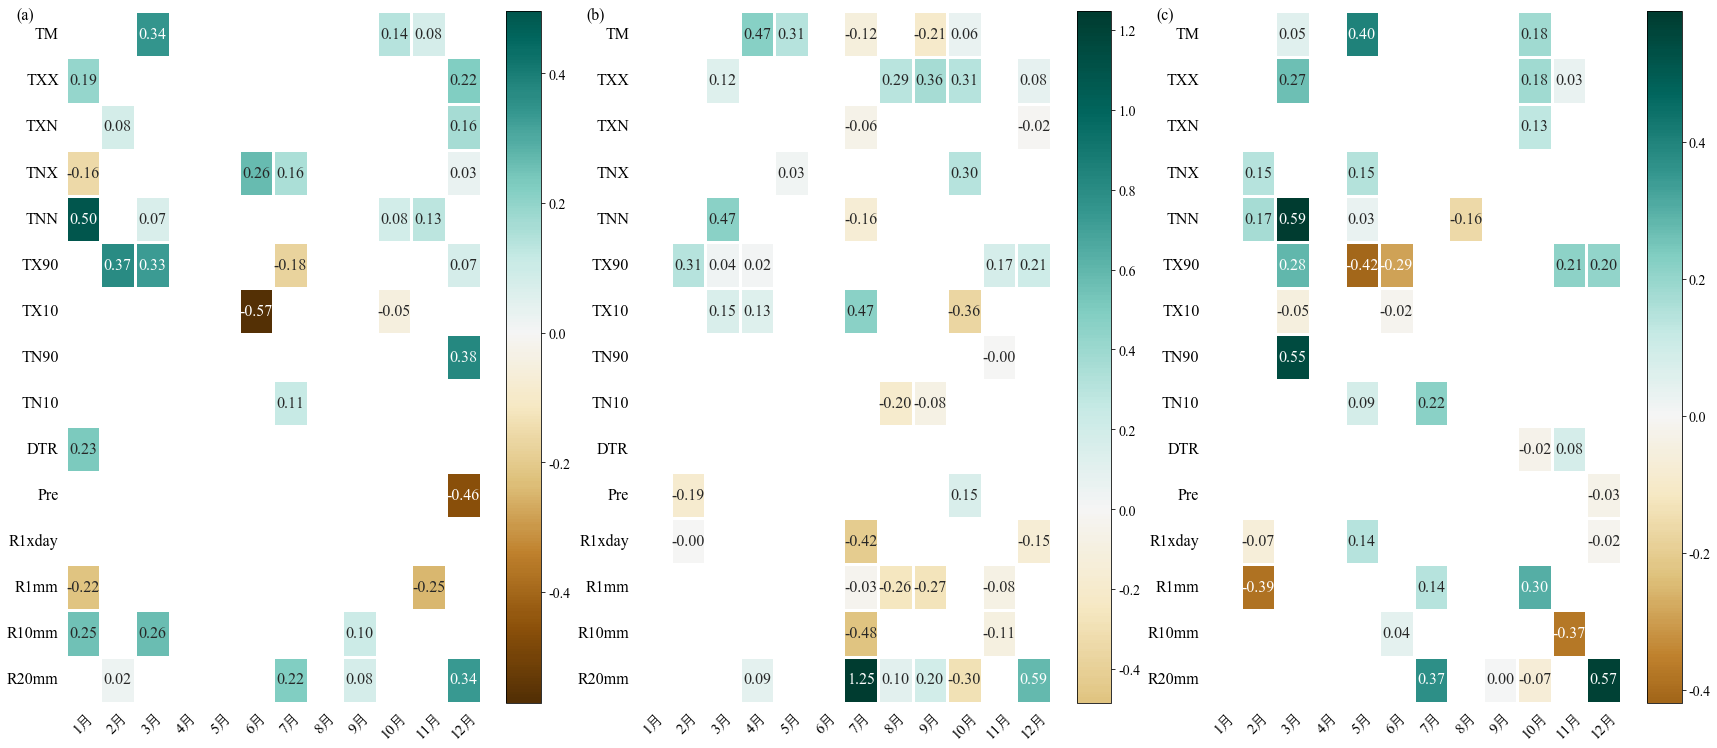

In [16]:

correlation_path = np.array(['G:/tudi_ndvi/month/output/1112_month_glm.npz','G:/tudi_ndvi/month/output/2124_month_glm.npz','G:/tudi_ndvi/month/output/3133_month_glm.npz'])

title = np.array(['(a)','(b)','(c)'])

fig=plt.figure(figsize=(10,8))
font_path = 'E:/chrome/tnw+simsun.ttf'
font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号


for k in range(3):
    correlation = np.load(correlation_path[k])
    indices_month_r = correlation['indices_coef']
    indices_month_r[indices_month_r == 0] = np.nan 
    ax2 = fig.add_axes([0.1+0.66*k, 0.1, 0.6, 0.8])
    #绘制热图
    ax2 = sns.heatmap(indices_month_r,cmap= 'BrBG',annot=True,center=0,linewidths=2.5,cbar=False,fmt=".2f")
    cb2=ax2.figure.colorbar(ax2.collections[0],ax=ax2) 
    cb2.ax.tick_params(labelsize=14) 
    ax2.set_xticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5],('1月','2月','3月','4月','5月','6月','7月','8月','9月','10月','11月','12月'),fontsize = 15,rotation=45)
    ax2.set_yticks([0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5,12.5,13.5,14.5],('TM','TXX','TXN','TNX','TNN','TX90','TX10','TN90','TN10','DTR','Pre','R1xday', 'R1mm', 'R10mm', 'R20mm'),style='italic',fontsize = 16,rotation=0)
    ax2.tick_params(axis='x', width=0)
    ax2.tick_params(axis='y', width=0)
    ax2.figure.set_size_inches(12,12)
    ax2.text(-0.12, 0.99, '{}'.format(title[k]), transform=ax2.transAxes)
                    
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\veg_month_glm.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

## 空间分布

c:\Users\86186\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1714: UserWarning: The following kwargs were not used by contour: 'projection'
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)


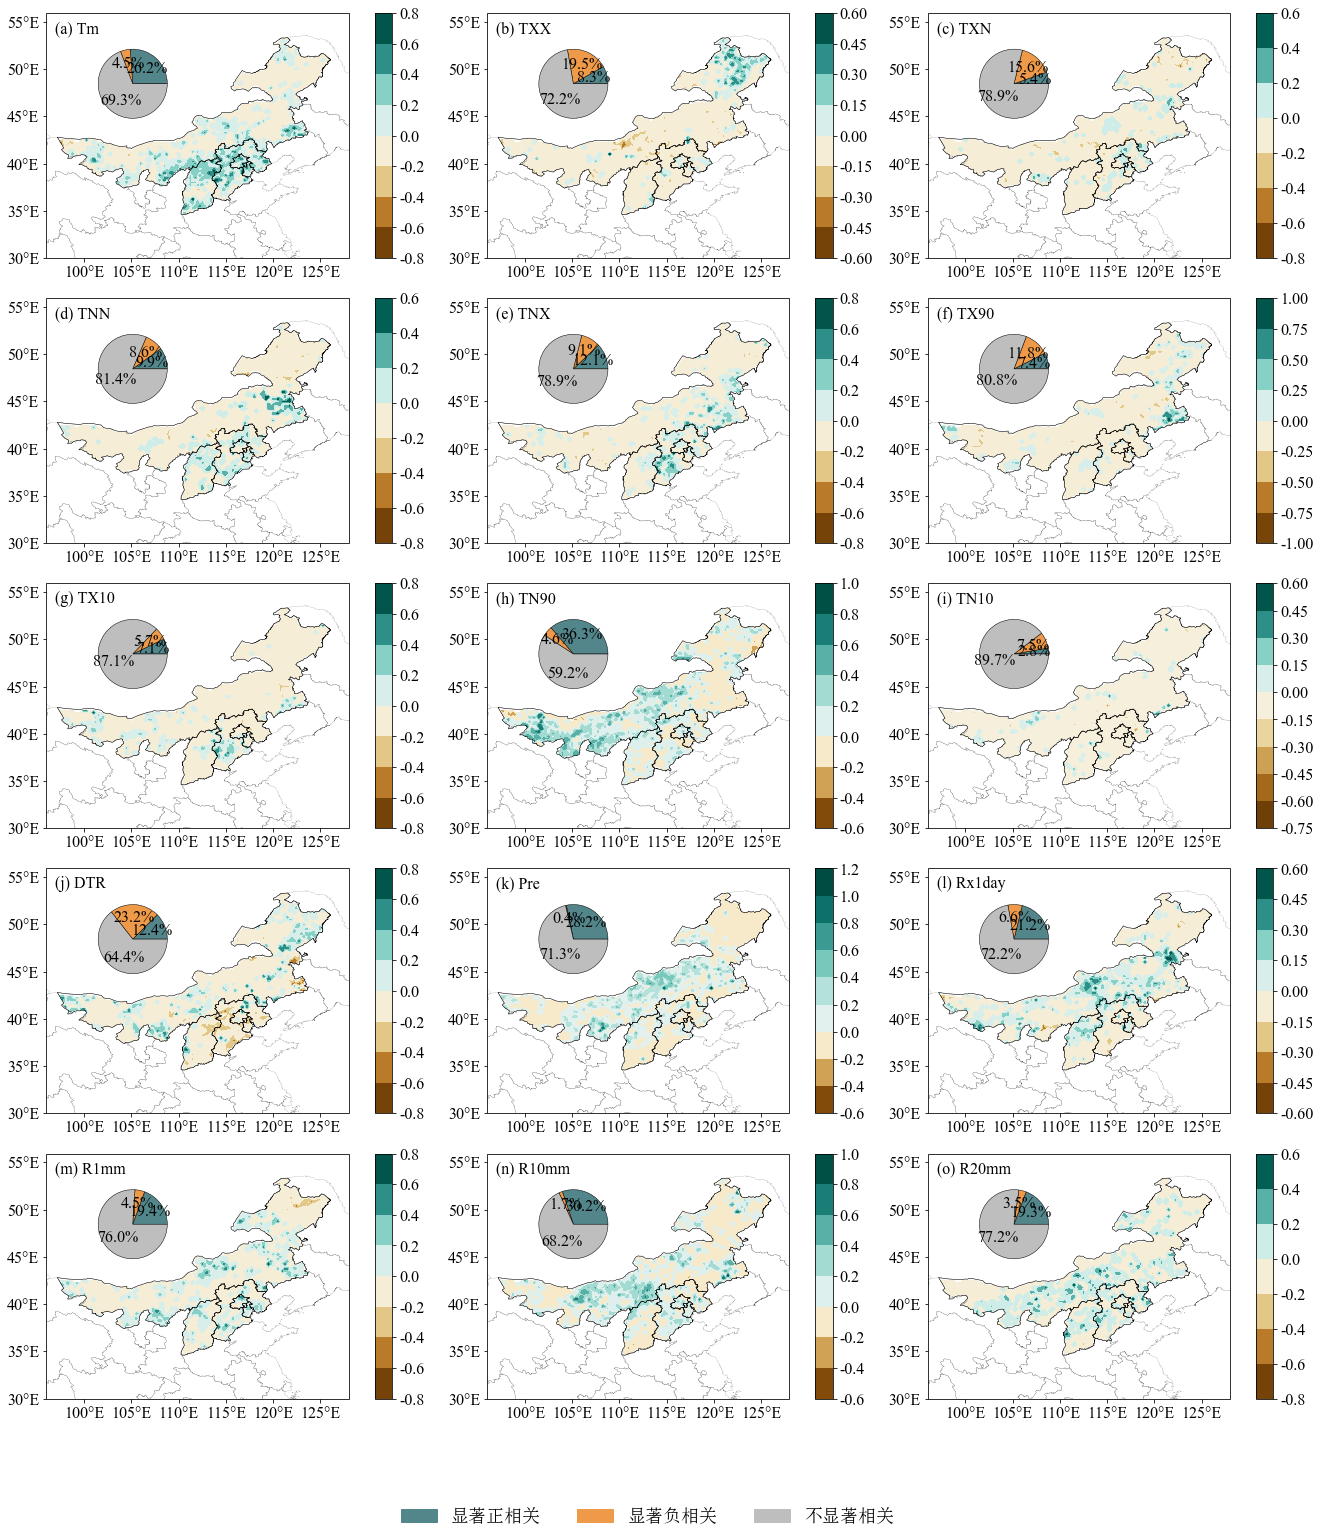

In [14]:
title = np.array(['(a) Tm','(b) TXX','(c) TXN','(d) TNN','(e) TNX','(f) TX90','(g) TX10','(h) TN90','(i) TN10','(j) DTR','(k) Pre','(l) Rx1day','(m) R1mm','(n) R10mm','(o) R20mm'])
title = title.reshape((5,3))
#读取文件
correlation =  np.load('G:/reserve/output/glm.npz')
indices_r = np.array(correlation['indices_coef'])

#读取npz文件
indices_year =  np.load(r'G:/cn05/cn05_huabei/output/indices_year.npz')

#其中有一些华北地区内的格点的值是0，此处不能够直接将所有0值变成np.nan，所以找了一个没有0值的进行规范范围。
TXX_year = np.array(indices_year['TXX'])
area = TXX_year[0]
area[np.isnan(area)]=0

#把数据中范围外为np.nan的值都替换成np.nan
indices_zero = np.full((15,101,141),fill_value=np.nan)

for i in range(15):
    a = indices_r[i,:,:]
    a[area==0]=np.nan
    indices_zero[i,:,:] = a

indices_r = indices_zero
huabei = sr.Reader('G:/cn05/huabeishp/output/huabei_area.shp')
china = sr.Reader('G:\cn05\全国图_实习用\区划\省.shp')

plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

#显著正相关，不显著正相关，显著负相关，不显著负相关
#进行循环，分为四种情况，画饼图
proportion = np.full((15,3),fill_value=0)
for k in range(15):
    for i in range(101):
        for j in range(141):
            if indices_r[k,i,j] > 0 :
                proportion[k,0] = proportion[k,0] + 1
            elif indices_r[k,i,j] < 0 :
                proportion[k,1] = proportion[k,1] + 1
            elif indices_r[k,i,j] == 0:
                proportion[k,2] = proportion[k,2] + 1


#把所有准备画图的数据进行变形，对应5行3列
indices_r = indices_r.reshape(5,3,101,141)
proportion = proportion.reshape(5,3,3)

lon = np.arange(95,130.25,0.25)
lat = np.arange(30,55.25,0.25)

fig=plt.figure(figsize=(12,12))
for i in range(5):
    for j in range(3):
        ax = fig.add_axes([0.1+j*0.51, 1.5-i*0.33, 0.35, 0.3],projection = ccrs.PlateCarree())
        ax.text(0.03, 0.92, '{}'.format(title[i,j]), transform=ax.transAxes)
        norm = TwoSlopeNorm(vcenter=0)
        r = ax.contourf(lon,lat,indices_r[i,j,:],norm = norm,cmap = 'BrBG',projection =ccrs.PlateCarree(central_longitude=112.5))
        ax.add_geometries(huabei.geometries(),ccrs.PlateCarree(),facecolor='none', edgecolor='black',linewidth=0.5)
        ax.add_geometries(china.geometries(),ccrs.PlateCarree(),facecolor='none', edgecolor='black',linewidth=0.1)
        ax.set_extent([96, 128, 30, 55])
        ax.set_xticks([100, 105, 110, 115, 120, 125],crs=ccrs.PlateCarree())
        ax.set_yticks([30, 35, 40, 45, 50, 55],crs=ccrs.PlateCarree())
        #出现经纬度标签
        ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
        ax.yaxis.set_major_formatter(cticker.LongitudeFormatter())
        cax = fig.add_axes([ax.get_position().x1+0.03,ax.get_position().y0,0.02,ax.get_position().height])
        fig.colorbar(r,cax = cax)
        ax2 = fig.add_axes([0.15+j*0.51, 1.66-i*0.33, 0.1, 0.1])
        ax2.axis('off')
        colors = ['#53868B','#EE9A49','#BEBEBE']
        ax2.pie(proportion[i,j,:],autopct='%1.1f%%',colors = colors,wedgeprops={'linewidth':0.5, 'edgecolor':'black'})

#设置图例分别对应三个颜色
patchs = [mpatches.Patch(color='#53868B', label='显著正相关'),mpatches.Patch(color='#EE9A49', label='显著负相关'),mpatches.Patch(color='#BEBEBE', label='不显著相关')]
#添加图例
fig.legend(handles=patchs,frameon=False,prop = {'size':18},bbox_to_anchor=(1.1,0.08),ncol = 3)


In [15]:
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\glm_Spatial.pdf',format='pdf',dpi=600,bbox_inches = 'tight')

c:\Users\86186\anaconda3\lib\site-packages\cartopy\mpl\geoaxes.py:1714: UserWarning: The following kwargs were not used by contour: 'projection'
  result = matplotlib.axes.Axes.contourf(self, *args, **kwargs)


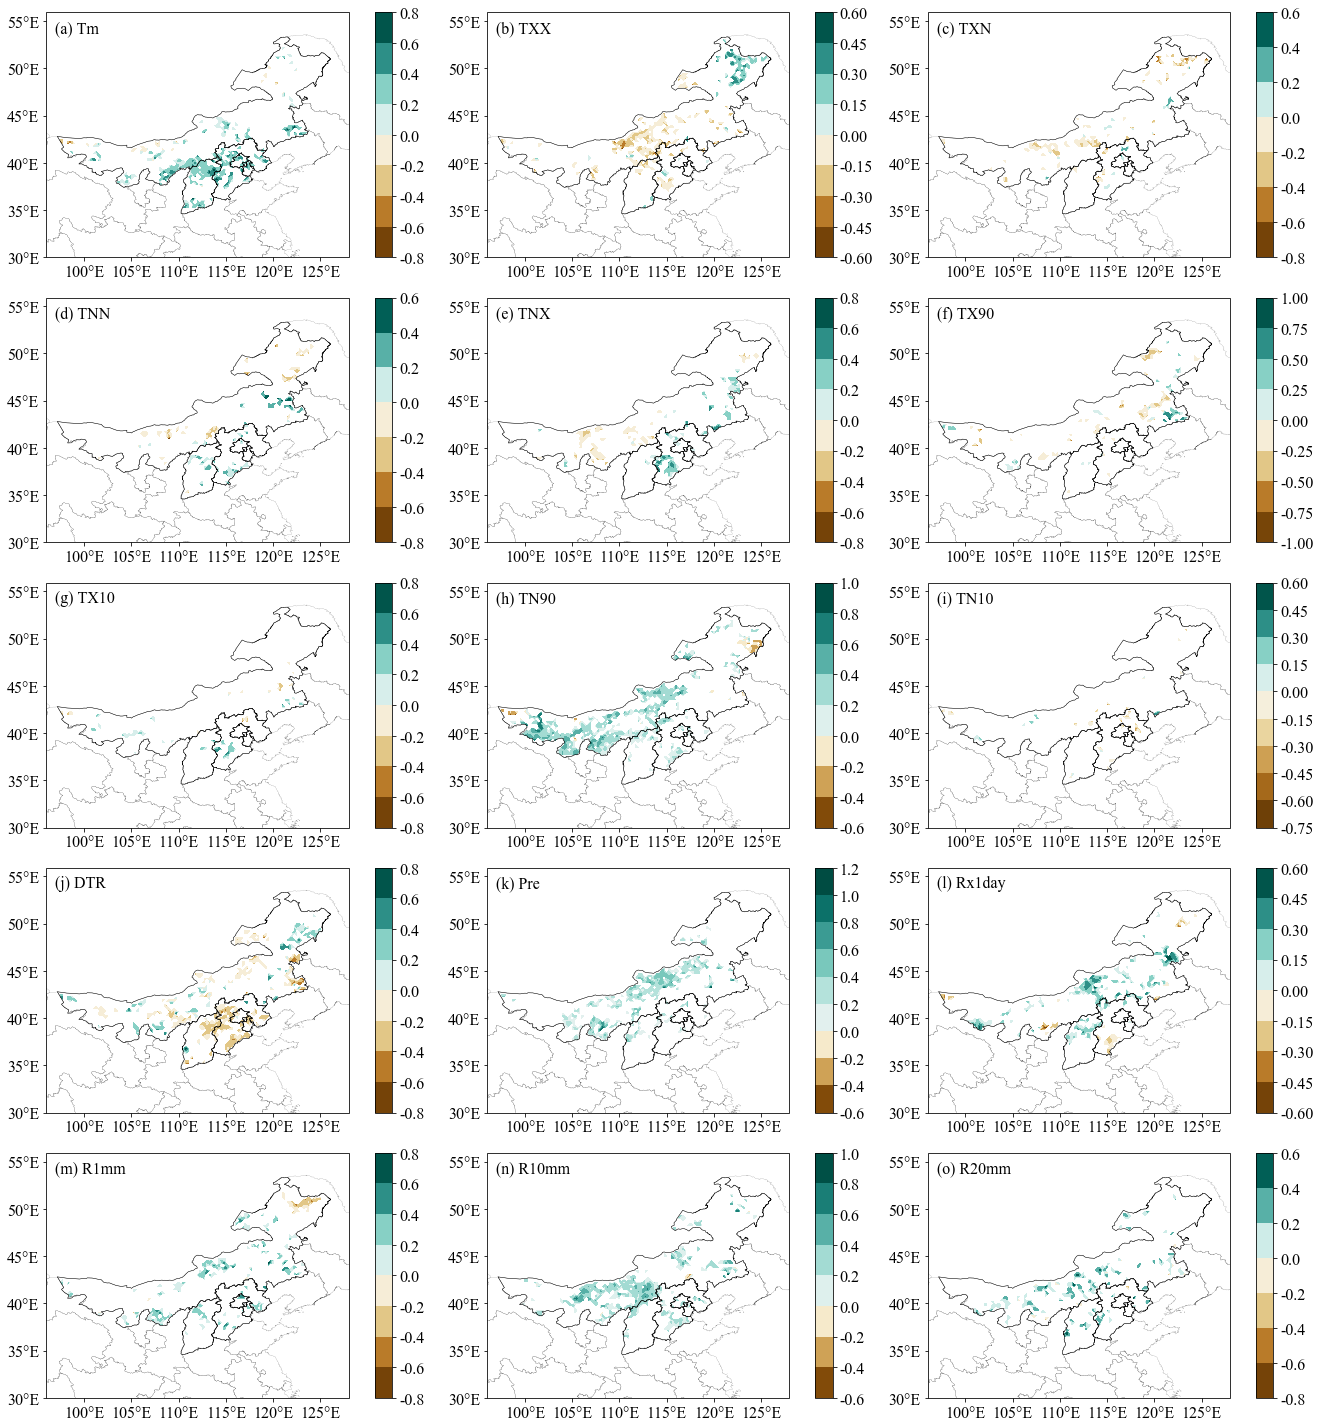

In [13]:
title = np.array(['(a) Tm','(b) TXX','(c) TXN','(d) TNN','(e) TNX','(f) TX90','(g) TX10','(h) TN90','(i) TN10','(j) DTR','(k) Pre','(l) Rx1day','(m) R1mm','(n) R10mm','(o) R20mm'])
title = title.reshape((5,3))
#读取文件
correlation =  np.load('G:/reserve/output/glm.npz')
indices_r = np.array(correlation['indices_coef'])

#读取npz文件
indices_year =  np.load(r'G:/cn05/cn05_huabei/output/indices_year.npz')

huabei = sr.Reader('G:/cn05/huabeishp/output/huabei_area.shp')
china = sr.Reader('G:\cn05\全国图_实习用\区划\省.shp')

plt.rcParams['font.family'] = 'sans-serif' # 使用字体中的无衬线体
plt.rcParams['font.sans-serif'] = prop.get_name()  # 根据名称设置字体
plt.rcParams['font.size'] = 16 # 设置字体大小
plt.rcParams['axes.unicode_minus'] = False # 使坐标轴刻度标签正常显示正负号

indices_r[indices_r == 0]=np.nan
#把所有准备画图的数据进行变形，对应5行3列
indices_r = indices_r.reshape(5,3,101,141)


lon = np.arange(95,130.25,0.25)
lat = np.arange(30,55.25,0.25)

fig=plt.figure(figsize=(12,12))
for i in range(5):
    for j in range(3):
        ax = fig.add_axes([0.1+j*0.51, 1.5-i*0.33, 0.35, 0.3],projection = ccrs.PlateCarree())
        ax.text(0.03, 0.92, '{}'.format(title[i,j]), transform=ax.transAxes)
        norm = TwoSlopeNorm(vcenter=0)
        r = ax.contourf(lon,lat,indices_r[i,j,:],norm = norm,cmap = 'BrBG',projection =ccrs.PlateCarree(central_longitude=112.5))
        ax.add_geometries(huabei.geometries(),ccrs.PlateCarree(),facecolor='none', edgecolor='black',linewidth=0.5)
        ax.add_geometries(china.geometries(),ccrs.PlateCarree(),facecolor='none', edgecolor='black',linewidth=0.1)
        ax.set_extent([96, 128, 30, 55])
        ax.set_xticks([100, 105, 110, 115, 120, 125],crs=ccrs.PlateCarree())
        ax.set_yticks([30, 35, 40, 45, 50, 55],crs=ccrs.PlateCarree())
        #出现经纬度标签
        ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
        ax.yaxis.set_major_formatter(cticker.LongitudeFormatter())
        cax = fig.add_axes([ax.get_position().x1+0.03,ax.get_position().y0,0.02,ax.get_position().height])
        fig.colorbar(r,cax = cax)


In [14]:
fig.savefig(r'E:\BaiduSyncdisk\lunwen\毕设的糟心玩意\figure\glm_Spatial_zero.pdf',format='pdf',dpi=600,bbox_inches = 'tight')